In [2]:
# imports
import pandas as pd
import os
import pdb
import shutil
from Bio import SeqIO

In [8]:
allTips = pd.read_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/Filtered_MetaTable_withManualGCF.tsv', sep='\t')

allTips['ManualLabel'] = allTips['ManualLabel'].str.lower()
allTips['Lichen'] = allTips['Lichen'].fillna('NotLichen')

# Figuring out all of the accessions that are lichen
allLichen = allTips[allTips['Lichen'] == 'Lichen']
#remove rows with no accession or species value
allLichen = allLichen[allLichen['Accession'].notna()]
allLichen = allLichen[allLichen['Species'].notna()]
accessionss = allLichen['Accession'].unique().tolist()
speciess = allLichen['Species'].unique().tolist()
# rem
# sort the accessions and species lists 
accessionss.sort()
speciess.sort()
accessionss
speciess

['Agyrium_rufum',
 'Bacidia_gigantensis',
 'Caloplaca_aegaea',
 'Caloplaca_aetnensis',
 'Caloplaca_ligustica',
 'Endocarpon_pusillum',
 'Gyalolechia_ehrenbergii',
 'Hypocenomyce_scalaris',
 'Icmadophila_ericetorum',
 'Lambiella_insularis',
 'Lasallia_pustulata',
 'Letrouitia_leprolyta',
 'Letrouitia_transgressa',
 'Lobaria_immixta',
 'Niorma_chrysophthalma',
 'Physcia_stellaris',
 'Pseudocyphellaria_aurata',
 'Schaereria_dolodes',
 'Seirophora_lacunosa',
 'Seirophora_villosa',
 'Sticta_canariensis',
 'Teloschistes_flavicans',
 'Teloschistes_peruensis',
 'Trapelia_coarctata',
 'Usnochroma_carphineum',
 'Variospora_aurantia',
 'Xanthomendoza_cf_fulva',
 'Xanthoria_aureola',
 'Xanthoria_mediterranea',
 'Xanthoria_sp_2_TBL2021',
 'Xanthoria_steineri',
 'Xylographa_bjoerkii',
 'Xylographa_carneopallida',
 'Xylographa_opegraphella',
 'Xylographa_pallens',
 'Xylographa_parallela',
 'Xylographa_soralifera',
 'Xylographa_trunciseda',
 'Xylographa_vitiligo']

## Step 0: Making the table for the R plotting

In [15]:
allTips = pd.read_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/Filtered_MetaTable_withManualGCF.tsv', sep='\t')

allTips['ManualLabel'] = allTips['ManualLabel'].str.lower()
allTips['Lichen'] = allTips['Lichen'].fillna('NotLichen')

allTips['MatchingNameInFasta'] = allTips['Protein'] + "_" + allTips['Accession']
# if the DB_Location is Lichen, make the MatchingNameInFasta the same as the TreeTip_Name
allTips.loc[allTips['DB_Location'] == 'Lichen', 'MatchingNameInFasta'] = allTips['TreeTip_Name'] + "_Singh"

## adding in the dit labels
ditPath = '/Volumes/T7/MiscProjects/Singh/FinalVersion/ManualLabels/dit.txt'
dit = pd.read_csv(ditPath, sep='\t', header=None)
dit.columns = ['TreeTip_Name']
# if the TreeTip_Name is in the dit file, then set the ManualLabel to 'dit'
allTips.loc[allTips['TreeTip_Name'].isin(dit['TreeTip_Name']), 'ManualLabel'] = 'dit'

## adding in the xan labels
xanPath = '/Volumes/T7/MiscProjects/Singh/FinalVersion/ManualLabels/xan.txt'
xan = pd.read_csv(xanPath, sep='\t', header=None)
xan.columns = ['TreeTip_Name']
# if the TreeTip_Name is in the xan file, then set the ManualLabel to 'xan'
allTips.loc[allTips['TreeTip_Name'].isin(xan['TreeTip_Name']), 'ManualLabel'] = 'xan'

saveHere = "/Volumes/T7/MiscProjects/Singh/April_FinalWork"
allTips.to_csv(os.path.join(saveHere, 'FinalMetaTable_April2025.tsv'), sep='\t', index=False)

In [13]:
allTips

,TreeTip_Name,DB_Location,Accession,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore,2023Nickles-etal_ClusterName,2023Nickles-etal__Dereplicated_GCF,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen,MatchingNameInFasta
0,Kluyveromyces_lactis_CAH01350.1,NCBI,GCA_000002515.1,CAH01350.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Kluyveromyces,Kluyveromyces_lactis,288.0,0.993103,NaN,NaN,NaN,dit,NotLichen,CAH01350.1_GCA_000002515.1
1,Candida_glabrata_CAG59009.1,NCBI,GCA_000002545.2,CAG59009.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,Candida_glabrata,281.0,0.968966,NaN,NaN,NaN,dit,NotLichen,CAG59009.1_GCA_000002545.2
2,Aspergillus_clavatus_EAW12213.1,NCBI,GCA_000002715.1,EAW12213.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,8_Aspergillus_clavatus,5.0,NaN,NaN,NotLichen,EAW12213.1_GCA_000002715.1
3,Aspergillus_clavatus_EAW12218.1,NCBI,GCA_000002715.1,EAW12218.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,10_Aspergillus_clavatus,5.0,NaN,NaN,NotLichen,EAW12218.1_GCA_000002715.1
4,Aspergillus_clavatus_EAW12455.1,NCBI,GCA_000002715.1,EAW12455.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,NaN,NaN,NaN,dit,NotLichen,EAW12455.1_GCA_000002715.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,Vezdaea_aestivalis_M1814_002798,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dit,Lichen,Vezdaea_aestivalis_M1814_002798_Singh
1921,Sticta_canariensis_MMC29_002054,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dit,Lichen,Sticta_canariensis_MMC29_002054_Singh
1922,Vezdaea_aestivalis_M1814_004225,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gcf_4,Lichen,Vezdaea_aestivalis_M1814_004225_Singh
1923,Arctoparmelia_centrifuga_FUN_000441,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen,Arctoparmelia_centrifuga_FUN_000441_Singh


## Goal 1: Download the gbks for all the genomes I used.

I created the script Code.py for this 

## Goal 2: Search all of the crm for the NRPS

In [13]:
allTips

,TreeTip_Name,DB_Location,Accession,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore,2023Nickles-etal_ClusterName,2023Nickles-etal__Dereplicated_GCF,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen
0,Kluyveromyces_lactis_CAH01350.1,NCBI,GCA_000002515.1,CAH01350.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Kluyveromyces,Kluyveromyces_lactis,288.0,0.993103,NaN,NaN,NaN,NaN,NaN
1,Candida_glabrata_CAG59009.1,NCBI,GCA_000002545.2,CAG59009.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,Candida_glabrata,281.0,0.968966,NaN,NaN,NaN,NaN,NaN
2,Aspergillus_clavatus_EAW12213.1,NCBI,GCA_000002715.1,EAW12213.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,8_Aspergillus_clavatus,5.0,NaN,NaN,NaN
3,Aspergillus_clavatus_EAW12218.1,NCBI,GCA_000002715.1,EAW12218.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,10_Aspergillus_clavatus,5.0,NaN,NaN,NaN
4,Aspergillus_clavatus_EAW12455.1,NCBI,GCA_000002715.1,EAW12455.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,Vezdaea_aestivalis_M1814_002798,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen
1921,Sticta_canariensis_MMC29_002054,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen
1922,Vezdaea_aestivalis_M1814_004225,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gcf_4,Lichen
1923,Arctoparmelia_centrifuga_FUN_000441,Lichen,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen


In [11]:
allTips = pd.read_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/Filtered_MetaTable_withManualGCF.tsv', sep='\t')

allTips['ManualLabel'] = allTips['ManualLabel'].str.lower()
crm = allTips[(allTips['ManualLabel'] == 'crm_fused') | (allTips['ManualLabel'] == 'crm_split')]
### Outgroup rows to add: Fusarium_coffeatum_XP_031013535.1, Fusarium_equiseti_CAG7566245.1
outGroupRows = allTips[allTips['TreeTip_Name'].isin(['Fusarium_coffeatum_XP_031013535.1', 'Fusarium_equiseti_CAG7566245.1'])]
crm = pd.concat([crm, outGroupRows], axis=0)

## Keeping only rows we want
crm = crm[['TreeTip_Name', 'DB_Location', 'Lichen','ManualLabel','Species','Genus','Accession','Protein']]
# All nan values in lichen column are replaced with 'NotLichen'
crm['Lichen'] = crm['Lichen'].fillna('NotLichen')
print(crm['Lichen'].value_counts())

### Removing duplicates between Annas database and Mine
RemoveThese = ['Xylographa_vitiligo_MMC15_000673',
'Xylographa_soralifera_MMC17_008632',
'Xylographa_pallens_MMC27_003017',
'Xylographa_opergraphella_MMC26_002878',
'Xylographa_carneopallida_MMC34_006463',
'Xylographa_bjoerkii_MMC18_000573',
'Variospora_aurantia_LQ341_001612',
'Usnochroma_carphineum',
'Sticta_canariensis_MMC29_006734',
'Seirophora_villosa',
'Seirophora_lacunosa',
'Icmadophila_ericetorum',
'Gyalolechia_ehrenbergii',
'Caloplaca_aetnensis',
'Caloplaca_aegaea',
'Bacidia_gigantensis_KY384_008841']
crm = crm[~crm['TreeTip_Name'].isin(RemoveThese)]
print(crm['Lichen'].value_counts())

crm.to_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/crmFinal.tsv', sep='\t', index=False)

NotLichen    377
Lichen        61
Name: Lichen, dtype: int64
NotLichen    377
Lichen        45
Name: Lichen, dtype: int64


In [12]:
output_crmTreeFiles = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/crmTree'

#our goal is to take the full fasta file, and filter it to only have the tree tips in the crm table
fastaPath = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/FullFasta_jan2025.faa'
# reading in the fasta file as a dictionary
icsFasta = SeqIO.to_dict(SeqIO.parse(fastaPath, 'fasta'))

crm['MatchingNameInFasta'] = crm['Protein'] + "_" + crm['Accession']
# if the DB_Location is Lichen, make the MatchingNameInFasta the same as the TreeTip_Name
crm.loc[crm['DB_Location'] == 'Lichen', 'MatchingNameInFasta'] = crm['TreeTip_Name'] + "_Singh"

crmProteins = crm['MatchingNameInFasta'].tolist()
#filtering the fasta file by this list 
filteredFasta = []
for crmProt in crmProteins:
    if crmProt in icsFasta:
        filteredFasta.append(icsFasta[crmProt])
    else:
        print(f"Protein {crmProt} not found in fasta file.")

## Renaming all of the record.id to the TreeTip_Name
for rec in filteredFasta:
    # get the TreeTip_Name from the crm table
    tipName = crm.loc[crm['MatchingNameInFasta'] == rec.id, 'TreeTip_Name'].values[0]
    # set the record.id to the TreeTip_Name
    rec.id = tipName
    rec.name = tipName
    rec.description = tipName

# 
# # Write to a FASTA file
crmFastaPath = os.path.join(output_crmTreeFiles, 'crm_outgroups.faa')
# with open(crmFastaPath, "w") as output_handle:
#     SeqIO.write(filteredFasta, output_handle, "fasta")



In [23]:
### The next step is to extract out the pf05141 domain from each of the records 
# Running hmmer
outputPath = os.path.join(output_crmTreeFiles, 'hmmsearch.out')
pfamPath = '/Volumes/T7/Pfams/Pfam-A.hmm'
cmd = f'hmmsearch -E 1e-5 --cpu 12 --tblout {outputPath} {pfamPath} {crmFastaPath}'
print(cmd)

hmmsearch -E 1e-5 --cpu 12 --tblout /Volumes/T7/MiscProjects/Singh/April_FinalWork/crmTree/hmmsearch.out /Volumes/T7/Pfams/Pfam-A.hmm /Volumes/T7/MiscProjects/Singh/April_FinalWork/crmTree/crm_outgroups.faa


The rest was finish in the FilterCrmProts.py file

## Goal 3: Extract out and anlyze the LFF BGCs

In [83]:
def extract_flanking_region(gbff_path, protein_id, output_gbk_path, flank=5):
    """
    Extracts 5 genes upstream and downstream of a given protein_id from a GBFF file.
    Saves the extracted region as a GenBank file.
    
    Parameters:
    - gbff_path (str): Path to the input GBFF file.
    - protein_id (str): Protein ID to search for.
    - output_gbk_path (str): Path to save the output GenBank file.
    - flank (int): Number of genes to include upstream and downstream.
    """
    for record in SeqIO.parse(gbff_path, "genbank"):
        for i, feature in enumerate(record.features):
            if feature.type == "CDS" and "protein_id" in feature.qualifiers:
                if protein_id in feature.qualifiers["protein_id"]:
                    start_index = max(i - flank, 0)
                    end_index = i + flank + 1
                    sub_features = record.features[start_index:end_index]

                    # Create a new record with subset features
                    new_record = record[start_index:end_index]
                    new_record.features = sub_features
                    new_record.annotations = record.annotations
                    new_record.id = f"{protein_id}_flanking"
                    new_record.name = f"{protein_id}_flanking"
                    new_record.description = f"Region around {protein_id} with {flank} genes flanking"

                    SeqIO.write(new_record, output_gbk_path, "genbank")
                    return f"Saved flanking region to {output_gbk_path}"
    
    return f"Protein ID {protein_id} not found in the GBFF file."

In [88]:
allTips = pd.read_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/Filtered_MetaTable_withManualGCF.tsv', sep='\t')

allTips['ManualLabel'] = allTips['ManualLabel'].str.lower()

lffs = allTips[(allTips['ManualLabel'] == 'lichengroup1') | (allTips['ManualLabel'] == 'lichengroup2')]

lffs['MatchingNameInFasta'] = lffs['Protein'] + "_" + lffs['Accession']
# if the DB_Location is Lichen, make the MatchingNameInFasta the same as the TreeTip_Name
lffs.loc[lffs['DB_Location'] == 'Lichen', 'MatchingNameInFasta'] = lffs['TreeTip_Name'] + "_Singh"

## Keeping only rows we want
lffs = lffs[['TreeTip_Name', 'DB_Location', 'Lichen','ManualLabel','Species','Genus','Accession','Protein']]
# All nan values in lichen column are replaced with 'NotLichen'
lffs['Lichen'] = lffs['Lichen'].fillna('NotLichen')
print(lffs['Lichen'].value_counts())

## Removing duplicates between Annas database and Mine
RemoveThese = ['Xylographa_vitiligo_MMC15_003146',
'Xylographa_vitiligo_MMC15_001555',
'Xylographa_trunciseda_MMC11_005954',
'Xylographa_trunciseda_MMC11_003068',
'Xylographa_soralifera_MMC17_003108',
'Xylographa_soralifera_MMC17_001664',
'Xylographa_pallens_MMC27_005897',
'Xylographa_opergraphella_MMC26_003333',
'Xylographa_opergraphella_MMC26_002626',
'Xylographa_carneopallida_MMC34_002691',
'Xylographa_bjoerkii_MMC18_003552',
'Variospora_aurantia_LQ341_000328',
'Sticta_canariensis_MMC29_007091',
'Pseudocyphellaria_aurata_FUN_006565',
'Lobaria_immixta']

lffs = lffs[~lffs['TreeTip_Name'].isin(RemoveThese)]
print(lffs['Lichen'].value_counts())

lffs.to_csv('/Volumes/T7/MiscProjects/Singh/April_FinalWork/lffsFinal.tsv', sep='\t', index=False)


Lichen       48
NotLichen     8
Name: Lichen, dtype: int64
Lichen       33
NotLichen     8
Name: Lichen, dtype: int64


/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_49548/3003944524.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lffs['MatchingNameInFasta'] = lffs['Protein'] + "_" + lffs['Accession']


In [87]:
# Using the extract_flanking_region function to extract the flanking regions for each protein
for prot in lffs.groupby(by = "Protein"):
    protDF = prot[1]
    tipName = protDF['TreeTip_Name'].values[0]
    protName = prot[0]
    pdb.set_trace()


,TreeTip_Name,DB_Location,Lichen,ManualLabel,Species,Genus,Accession,Protein
595,Lophium_mytilinum_KAF2488791.1,NCBI,NotLichen,lichengroup1,Lophium_mytilinum,Lophium,GCA_010093605.1,KAF2488791.1
601,Plenodomus_tracheiphilus_KAF2848073.1,NCBI,NotLichen,lichengroup1,Plenodomus_tracheiphilus,Plenodomus,GCA_010093695.1,KAF2848073.1
617,Delitschia_confertaspora_KAF2201234.1,NCBI,NotLichen,lichengroup1,Delitschia_confertaspora,Delitschia,GCA_010093945.1,KAF2201234.1
660,Botryosphaeria_dothidea_KAF4307270.1,NCBI,NotLichen,lichengroup1,Botryosphaeria_dothidea,Botryosphaeria,GCA_011503125.2,KAF4307270.1
818,Endocarpon_pusillum_KAF7507277.1,NCBI,Lichen,lichengroup1,Endocarpon_pusillum,Endocarpon,GCA_014607435.1,KAF7507277.1
1050,Phaeosphaeriaceae_sp_PMI808_KAH8728392.1,NCBI,NotLichen,lichengroup1,Phaeosphaeriaceae_sp_PMI808,NaN,GCA_021365335.1,KAH8728392.1
1086,Leptosphaeria_biglobosa_KAH9877667.1,NCBI,NotLichen,lichengroup1,Leptosphaeria_biglobosa,Leptosphaeria,GCA_022343325.1,KAH9877667.1
1262,Xylographa_vitiligo_MCJ1316234.1,NCBI,Lichen,lichengroup2,Xylographa_vitiligo,Xylographa,GCA_022813765.1,MCJ1316234.1
1263,Xylographa_vitiligo_MCJ1317819.1,NCBI,Lichen,lichengroup1,Xylographa_vitiligo,Xylographa,GCA_022813765.1,MCJ1317819.1
1264,Xylographa_trunciseda_MCJ1399865.1,NCBI,Lichen,lichengroup2,Xylographa_trunciseda,Xylographa,GCA_022813785.1,MCJ1399865.1


## Goal 4: Blast for the NRPS gene, and measure how close it is to the ICS gene

In [13]:
## Reading in the query NRPS 
queryNRPS_path = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/query_NRPSRegion.faa'
queryNRPS = SeqIO.to_dict(SeqIO.parse(queryNRPS_path, 'fasta'))
gbffFolder = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/GBKs_AllGenomes'
blastingFastaPath = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm'

def process_row(row):
    accession = row['Accession']
    if accession == 'None':
        return f"Skipped accession 'None'"
    
    gbffPath = os.path.join(gbffFolder, f"{accession}.gbff")
    if not os.path.isfile(gbffPath):
        return f"GBFF file for {accession} not found."
    
    try:
        genome = list(SeqIO.parse(gbffPath, 'genbank'))
        for contig in genome:
            contig.id = f"{accession}_{contig.id}"
        fastaPath = os.path.join(blastingFastaPath, f"{accession}.fna")
        SeqIO.write(genome, fastaPath, 'fasta')
        return f"Written: {fastaPath}"
    except Exception as e:
        return f"Error processing {accession}: {str(e)}"

# Apply function for parallel processing
from concurrent.futures import ThreadPoolExecutor
# filtering out all of the accessions from the crm table if the accession is already in the blastingFastaPath

alreadyDone = os.listdir(blastingFastaPath)
# keeping on files that start with GC and end with .fna
alreadyDone = [x for x in alreadyDone if x.startswith('GC') and x.endswith('.fna')]
alreadyDone = [".".join(x.split('.')[0:2]) for x in alreadyDone]
crm_filtered = crm[~crm['Accession'].isin(alreadyDone)]

print(f"Number of accessions to process: {len(crm_filtered)}")

with ThreadPoolExecutor() as executor:
    results = list(executor.map(process_row, [row for _, row in crm_filtered.iterrows()]))



Number of accessions to process: 19


In [19]:
crm

,TreeTip_Name,DB_Location,Lichen,ManualLabel,Species,Genus,Accession,Protein,MatchingNameInFasta
12,Grosmannia_clavigera_EFX05940.1,NCBI,NotLichen,crm_fused,Grosmannia_clavigera,Grosmannia,GCA_000143105.2,EFX05940.1,EFX05940.1_GCA_000143105.2
13,Aspergillus_fischeri_EAW21206.1,NCBI,NotLichen,crm_fused,Aspergillus_fischeri,Aspergillus,GCA_000149645.3,EAW21206.1,EAW21206.1_GCA_000149645.3
18,Trichophyton_equinum_EGE05591.1,NCBI,NotLichen,crm_fused,Trichophyton_equinum,Trichophyton,GCA_000151175.1,EGE05591.1,EGE05591.1_GCA_000151175.1
21,Trichoderma_virens_EHK24062.1,NCBI,NotLichen,crm_fused,Trichoderma_virens,Trichoderma,GCA_000170995.2,EHK24062.1,EHK24062.1_GCA_000170995.2
24,Trichoderma_atroviride_EHK42400.1,NCBI,NotLichen,crm_fused,Trichoderma_atroviride,Trichoderma,GCA_000171015.2,EHK42400.1,EHK42400.1_GCA_000171015.2
...,...,...,...,...,...,...,...,...,...
1876,Alectoria_fallacina,Lichen,Lichen,crm_split,NaN,NaN,None,None,Alectoria_fallacina_Singh
1877,Agyrium_rufum_FUN_008167,Lichen,Lichen,crm_split,NaN,NaN,None,None,Agyrium_rufum_FUN_008167_Singh
1881,Chaenotheca_gracillima,Lichen,Lichen,crm_split,NaN,NaN,None,None,Chaenotheca_gracillima_Singh
1434,Fusarium_equiseti_CAG7566245.1,NCBI,NotLichen,gcf_6,Fusarium_equiseti,Fusarium,GCA_910393935.1,CAG7566245.1,CAG7566245.1_GCA_910393935.1


In [6]:
## Step 2: Combining all of the fasta files into one file
cmd = f"cat {blastingFastaPath}/GC*.fna > {blastingFastaPath}/allGenomes.fna"
print(cmd)

cat /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/GC*.fna > /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/allGenomes.fna


In [7]:
## Step 3: Creating a blast database
cmd = f"makeblastdb -in {blastingFastaPath}/allGenomes.fna -dbtype nucl -out {blastingFastaPath}/allGenomesDB"
print(cmd)

makeblastdb -in /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/allGenomes.fna -dbtype nucl -out /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/allGenomesDB


In [8]:
## Step 4: Running TBLASTN from the protein NRPS query
cmd = f"tblastn -query {queryNRPS_path} -db {blastingFastaPath}/allGenomesDB -outfmt 6 -evalue 1e-5 -out {blastingFastaPath}/NRPS_TBlastN.out"
print(cmd)

tblastn -query /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/query_NRPSRegion.faa -db /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/allGenomesDB -outfmt 6 -evalue 1e-5 -out /Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_TBlastN.out


In [50]:
## Step 5: Reading in the TBLASTN output
tblastn_output_path = os.path.join(blastingFastaPath, 'NRPS_TBlastN.out')
tblastn_output = pd.read_csv(tblastn_output_path, sep='\t', header=None)
tblastn_output.columns = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
tblastn_output['Accession'] = tblastn_output['sseqid'].str.split('_').str[0:2]
tblastn_output['Accession'] = tblastn_output['Accession'].apply(lambda x: "_".join(x))

In [52]:
tblastn_output

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,Accession
0,GCA_020501355.1_KAH2552755.1,GCA_000149645.3_DS027690.1,85.609,1216,102,6,1,1144,603137,599493,0.000000e+00,2040.0,GCA_000149645.3
1,GCA_020501355.1_KAH2552755.1,GCA_002234965.2_NKHV02000085.1,83.848,1133,136,6,55,1144,57681,61067,0.000000e+00,1892.0,GCA_002234965.2
2,GCA_020501355.1_KAH2552755.1,GCA_002234965.2_NKHV02000085.1,78.689,61,13,0,1,61,57448,57630,1.590000e-20,107.0,GCA_002234965.2
3,GCA_020501355.1_KAH2552755.1,GCF_000187405.1_NW_006916681.1,69.356,1227,289,6,3,1144,146038,149712,0.000000e+00,1702.0,GCF_000187405.1
4,GCA_020501355.1_KAH2552755.1,GCA_001858085.1_DAAX01000011.1,68.494,1222,299,7,2,1143,41984,38337,0.000000e+00,1699.0,GCA_001858085.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1598,GCA_020501355.1_KAH2552755.1,GCA_022813885.1_JALDZW010000001.1,29.114,237,139,3,78,291,126692,126000,1.540000e-75,110.0,GCA_022813885.1
1599,GCA_020501355.1_KAH2552755.1,GCA_022813885.1_JALDZW010000001.1,27.027,74,49,1,2,70,127026,126805,1.540000e-75,36.2,GCA_022813885.1
1600,GCA_020501355.1_KAH2552755.1,GCF_001481775.1_NW_017386925.1,30.016,613,383,17,21,596,24496,26307,2.180000e-75,283.0,GCF_001481775.1
1601,GCA_020501355.1_KAH2552755.1,GCA_022813825.1_JALDZZ010000022.1,32.645,533,337,10,78,596,133715,135289,2.260000e-75,283.0,GCA_022813825.1


In [42]:
## Step 6: Parsing the blast results to see where the NRPS was relative to the crm hits
def GetContig_Start_Stop_OfProtein(genome, proteinName):
    """
    Given a genome and a protein name, return the contig ID of the protein.
    """
    for contig in genome:
        # getting all of the features 
        cds_features = [f for f in contig.features if f.type == 'CDS' and 'protein_id' in f.qualifiers]
        for i, feature in enumerate(cds_features):
            if feature.type == 'CDS' and 'protein_id' in feature.qualifiers:
                if proteinName in feature.qualifiers['protein_id']:
                    pdb.set_trace()
                    start = feature.location.start
                    stop = feature.location.end
                    contig = contig.id
                    return [contig, start, stop]
    return None

In [41]:
#Creating the final table 
nrps_crm_df = pd.DataFrame(columns=['Accession', 'Species', 'crm_protein', 'crm_contig', 'crm_start', 'crm_end', 'nrps_protein','nrps_contig','nrps_start','nrps_stop', 'genes_seperating','crm_proteinSeq', 'nrps_proteinSeq','Lichen'])
crm_append = crm[crm['Accession'] != 'None']
crm_append = crm_append[['Accession','Protein','Species','Lichen']]
crm_append.rename(columns={'Protein':'crm_protein'}, inplace=True)
# appending this to the final table
nrps_crm_df = pd.concat([nrps_crm_df, crm_append], axis=0)

## DELETE AFTER TESTING IS DONE
counter = 0

for accession in nrps_crm_df.groupby(by="Accession"):
    acc = accession[0]
    accDF = accession[1]
    ## Get the genome gbk file
    genome_gbk = os.path.join(gbffFolder, f"{acc}.gbff")
    genome = SeqIO.parse(genome_gbk, 'genbank')
    accBlastResults_DF = tblastn_output[tblastn_output['Accession'] == acc]
    ## We need to do the next step for each crm copy 
    for index, row in accDF.iterrows():
        crm_protein = row['crm_protein']
        crm_location = GetContig_Start_Stop_OfProtein(genome, crm_protein)
        try: 
            crm_start = crm_location[1]
            crm_stop = crm_location[2]
            crm_contig = crm_location[0]
        except:
            print(f"Error getting crm location for {crm_protein} in {acc}")
            pdb.set_trace()
        ## updating the final table with the crm values
        nrps_crm_df.loc[index, 'crm_contig'] = crm_contig 
        nrps_crm_df.loc[index, 'crm_start'] = crm_start 
        nrps_crm_df.loc[index, 'crm_end'] = crm_stop

    counter += 1
    if counter % 10 == 0:
        print(f"Processed {counter} accessions")



Processed 10 accessions
Error getting crm location for EMT71253.1 in GCA_000350365.1
> /var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_90198/2173210353.py(48)<module>()
     46             pdb.set_trace()
     47         ## updating the final table with the crm values
---> 48         nrps_crm_df.loc[index, 'crm_contig'] = crm_contig
     49         nrps_crm_df.loc[index, 'crm_start'] = crm_start
     50         nrps_crm_df.loc[index, 'crm_end'] = crm_stop

('GCA_000350365.1',           Accession                 Species crm_protein crm_contig crm_start  \
57  GCA_000350365.1  Fusarium_odoratissimum  EMT69002.1        NaN       NaN   
58  GCA_000350365.1  Fusarium_odoratissimum  EMT71253.1        NaN       NaN   

   crm_end nrps_protein nrps_contig nrps_start nrps_stop genes_seperating  \
57     NaN          NaN         NaN        NaN       NaN              NaN   
58     NaN          NaN         NaN        NaN       NaN              NaN   

   crm_proteinSeq nrps_proteinSeq  

In [43]:
acc = "GCA_000350365.1"
genome_gbk = os.path.join(gbffFolder, f"{acc}.gbff")
genome = SeqIO.parse(genome_gbk, 'genbank')
GetContig_Start_Stop_OfProtein(genome, crm_protein)

> /var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_90198/565112334.py(13)GetContig_Start_Stop_OfProtein()
     11                 if proteinName in feature.qualifiers['protein_id']:
     12                     pdb.set_trace()
---> 13                     start = feature.location.start
     14                     stop = feature.location.end
     15                     contig = contig.id

SeqFeature(CompoundLocation([FeatureLocation(ExactPosition(737270), ExactPosition(738104), strand=1), FeatureLocation(ExactPosition(738153), ExactPosition(738786), strand=1)], 'join'), type='CDS', location_operator='join')


In [9]:
import pdb
import pandas as pd
## Printing the total number of Lecanoromycetes genomes we had in the database sup table 1
supTable1 = pd.read_csv('/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv', sep='\t')
lec = supTable1[supTable1['Fungal_Class'] == 'Lecanoromycetes']

## Randomize the table and print five unique species 
lec = lec.sample(frac=1).reset_index(drop=True)
### keep onlyl the one's with ICS
lec_ics = lec[lec['ICS_Count'] > 0]
lecSpp = lec_ics[['Species', 'Accession', 'ICS_Count']]
lecSpp = lecSpp.drop_duplicates(subset=['Species'])
# sort by ics count
lecSpp = lecSpp.sort_values(by='ICS_Count', ascending=False)
lecSpp = lecSpp.reset_index(drop=True)
print(f'The five top species are:')
for index, row in lecSpp.iterrows():
	print(f"Species: {row['Species']}, Accession: {row['Accession']}, ICS_Count: {row['ICS_Count']}")

The five top species are:
Species: Letrouitia_leprolyta, Accession: GCA_023646175.1, ICS_Count: 5
Species: Usnochroma_carphineum, Accession: GCA_023645975.1, ICS_Count: 5
Species: Gyalolechia_ehrenbergii, Accession: GCA_023646125.1, ICS_Count: 5
Species: Teloschistes_peruensis, Accession: GCA_023645835.1, ICS_Count: 4
Species: Xylographa_bjoerkii, Accession: GCA_022813905.1, ICS_Count: 4
Species: Sticta_canariensis, Accession: GCA_022814045.1, ICS_Count: 3
Species: Xylographa_soralifera, Accession: GCA_022813805.1, ICS_Count: 3
Species: Pseudocyphellaria_aurata, Accession: GCA_022814125.1, ICS_Count: 3
Species: Xylographa_opegraphella, Accession: GCA_022813865.1, ICS_Count: 3
Species: Trapelia_coarctata, Accession: GCA_022813945.1, ICS_Count: 3
Species: Xylographa_vitiligo, Accession: GCA_022813765.1, ICS_Count: 3
Species: Xanthoria_aureola, Accession: GCA_023646375.1, ICS_Count: 2
Species: Variospora_aurantia, Accession: GCA_023645955.1, ICS_Count: 2
Species: Xylographa_parallela, Acc

In [6]:
lec

,Accession,ICS_Count,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore
0,GCA_022814265.1,1,Fungi,Ascomycota,Lecanoromycetes,Trapeliales,Trapeliaceae,Lambiella,Lambiella_insularis,270.0,0.931034
1,GCA_022813995.1,0,Fungi,Ascomycota,Lecanoromycetes,Ostropales,Graphidaceae,Thelotrema,ManuallyGetSpecies,0.0,0.000000
2,GCA_023646365.1,1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,Xanthomendoza,Xanthomendoza_cf_fulva,275.0,0.948276
3,GCF_014066315.1,0,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Letharia,Letharia_lupina,283.0,0.975862
4,GCA_022813765.1,3,Fungi,Ascomycota,Lecanoromycetes,Trapeliales,Trapeliaceae,Xylographa,Xylographa_vitiligo,276.0,0.951724
...,...,...,...,...,...,...,...,...,...,...,...
56,GCA_019456465.1,1,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Ramalinaceae,Bacidia,Bacidia_gigantensis,256.0,0.882759
57,GCA_023645885.1,2,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,Caloplaca,Caloplaca_ligustica,245.0,0.844828
58,GCA_023646395.1,2,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,Xanthoria,Xanthoria_sp_1_TBL2021,225.0,0.775862
59,GCA_023646655.1,1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,Caloplaca,Caloplaca_aegaea,255.0,0.879310


## Creating the gene arrows for the crm tree

In [105]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

crmMeta = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_CRM_FinalTable.tsv", sep='\t')

synthaserFasta_list = []
for index, row in crmMeta.iterrows():
    crmProtSeq = row['crm_proteinSeq']
    crmProt_Name = row['crm_protein']
    acc = row['Accession']
    species = row['Species']
    nrpsProtSeq = row['nrps_proteinSeq']
    nrpsProt_Name = row['nrps_protein']
    # checking if the nrps is the same as crm protein 
    crm_IDName = species + "_" + crmProt_Name
    seq_crm = SeqRecord(Seq(crmProtSeq), id=crm_IDName, description=f"{acc}_{crmProt_Name}")
    if nrpsProtSeq == "None" or nrpsProtSeq == "SameAs_crm":
        #only add the crm protein Seq 
        synthaserFasta_list.append(seq_crm)
    else: # add both the crm and nrps protein Seq
        nrps_IDName = species + "_" + nrpsProt_Name
        seq_nrps = SeqRecord(Seq(nrpsProtSeq), id=crm_IDName, description=f"{acc}_{nrpsProt_Name}")
        synthaserFasta_list.append(seq_nrps)

# Write to a FASTA file
saveHere = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun"
synthaserFastaPath = os.path.join(saveHere, 'synthaser_allcrm.faa')
with open(synthaserFastaPath, "w") as output_handle:
    SeqIO.write(synthaserFasta_list, output_handle, "fasta")


## Analyzing the synthaser table

In [112]:
synthaserResults = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun/crm_domainGrouping.txt", sep="\t")
colNames = ["crmProtein_Key","DomainsInEnzyme"]
synthaserResults.columns = colNames
## Creating a column that edits out ICS- 
synthaserResults['DomainsInEnzyme_NoICS'] = synthaserResults['DomainsInEnzyme'].str.replace("ICS-", "")
synthaserResults = synthaserResults[synthaserResults['DomainsInEnzyme'] != "ICS"]

## Print out all of the unique values in the "DomainsInEnzyme" column with there counts
domainCounts = synthaserResults.value_counts("DomainsInEnzyme_NoICS")
## Convert to dataframe 
domainCounts = domainCounts.reset_index()
domainCounts.columns = ['DomainsInEnzyme_NoICS', 'Counts']
## sort from high to low
domainCounts = domainCounts.sort_values(by='Counts', ascending=False)

domainCounts['GroupLetter'] = ""
startingLetter = "a"
for index, row in domainCounts.iterrows():
    domainsString = row['DomainsInEnzyme_NoICS']
    print(f"Domain Name: {domainsString} is being set to the letter {startingLetter}")
    synthaserResults.loc[synthaserResults['DomainsInEnzyme_NoICS'] == domainsString, 'GroupLetter'] = startingLetter
    # setting the letter to the next in the alphabet
    domainCounts.loc[index, 'GroupLetter'] = startingLetter
    startingLetter = chr(ord(startingLetter) + 1)

#drop rows where the group letter is NaN
synthaserResults.dropna(subset=['GroupLetter'], inplace=True)
## Saving the results

saveHere = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun"
synthaserResultsPath = os.path.join(saveHere, 'synthaser_domainGrouping.tsv')
synthaserResults.to_csv(synthaserResultsPath, sep="\t", index=False)

## Saving the domain results
domainCountsPath = os.path.join(saveHere, 'synthaser_domainCounts.tsv')
domainCounts.to_csv(domainCountsPath, sep="\t", index=False)

Domain Name: A-T-Omega-hydroxypalmitate O-feruloyl transferase is being set to the letter a
Domain Name: A-T is being set to the letter b
Domain Name: A-T-TR is being set to the letter c
Domain Name: A-T-Omega-hydroxypalmitate O-feruloyl transferase-ARN_Family_MetalTransporter is being set to the letter d
Domain Name: A is being set to the letter e
Domain Name: ACP-Omega-hydroxypalmitate O-feruloyl transferase is being set to the letter f
Domain Name: A-TR is being set to the letter g
Domain Name: A-ER-T-Omega-hydroxypalmitate O-feruloyl transferase is being set to the letter h
Domain Name: A-Omega-hydroxypalmitate O-feruloyl transferase is being set to the letter i
Domain Name: A-T-ICS is being set to the letter j
Domain Name: A-T-Omega-hydroxypalmitate O-feruloyl transferase-T is being set to the letter k


## Grabbing different key proteins from the table

In [120]:
fullMetaTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Plots/crmMeta.tsv", sep="\t")

startingLetter = "b"
endLetter = fullMetaTable.sort_values("GroupLetter")['GroupLetter'].unique().tolist()[-2]
curLetter = startingLetter
while curLetter != endLetter:
    groupDF = fullMetaTable[fullMetaTable['GroupLetter'] == curLetter]
    splitGroup = groupDF[groupDF['NRPS_attached_ICS'] == "No"]
    fusedGroup = groupDF[groupDF['NRPS_attached_ICS'] == "Yes"]
    saveThese = []
    if len(fusedGroup) > 0:
        # Get the first row of the fusedGroup dataframe
        fusedRow = fusedGroup.iloc[0]
        # we want to save the crm protein sequence
        crmProtSeq = fusedRow['crm_proteinSeq']
        crmProt_Name = fusedRow['crm_protein']
        seq_crm = SeqRecord(Seq(crmProtSeq), id=crmProt_Name, description=f"{acc}_{crmProt_Name}")
        saveThese.append(seq_crm)
    if len(splitGroup) > 0:
        # Get the first row of the splitGroup dataframe
        splitRow = splitGroup.iloc[0]
        # we want to save the nrps protein sequence
        nrpsProtSeq = splitRow['nrps_proteinSeq']
        nrpsProt_Name = splitRow['nrps_protein']
        seq_nrps = SeqRecord(Seq(nrpsProtSeq), id=nrpsProt_Name, description=f"{acc}_{nrpsProt_Name}")
        saveThese.append(seq_nrps)
    ## Saving the results
    fastaFolder = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun'
    #writing the saved sequences to a fasta file
    fileName = "Type" + curLetter.upper() + ".faa"
    savePath = os.path.join(fastaFolder, fileName)
    with open(savePath, "w") as output_handle:
        SeqIO.write(saveThese, output_handle, "fasta")
    
    ### Running synthaser on all of the files
    cmd = 

    # set the current letter to the next letter in the alphabet
    curLetter = chr(ord(curLetter) + 1)


In [91]:
synthaserResults = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun/crm_domainGrouping.txt", sep="\t")
colNames = ["crmProtein_Key","DomainsInEnzyme"]
synthaserResults.columns = colNames
## Print out all of the unique values in the "DomainsInEnzyme" column with there counts
domainCounts = synthaserResults.value_counts("DomainsInEnzyme")
## Convert to dataframe 
domainCounts = domainCounts.reset_index()
domainCounts.columns = ['DomainsInEnzyme', 'Counts']
## sort from high to low
domainCounts = domainCounts.sort_values(by='Counts', ascending=False)
removeRows = ['ICS']
domainCounts = domainCounts[~domainCounts['DomainsInEnzyme'].isin(removeRows)]


In [97]:
synthaserResults = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun/crm_domainGrouping.txt", sep="\t")
colNames = ["crmProtein_Key","DomainsInEnzyme"]
synthaserResults.columns = colNames
## Drop the monodomain ICS row
synthaserResults = synthaserResults[synthaserResults['DomainsInEnzyme'] != 'ICS']
## Creating a column that edits out ICS- 
synthaserResults['DomainsInEnzyme_NoICS'] = synthaserResults['DomainsInEnzyme'].str.replace("ICS-", "")

## Print out all of the unique values in the "DomainsInEnzyme" column with there counts
domainCounts = synthaserResults.value_counts("DomainsInEnzyme_NoICS")
domainCounts

DomainsInEnzyme_NoICS
A-T-Omega-hydroxypalmitate O-feruloyl transferase                                248
A-T                                                                               37
A-T-TR                                                                            19
A-T-Omega-hydroxypalmitate O-feruloyl transferase-ARN_Family_MetalTransporter     17
A                                                                                  6
ACP-Omega-hydroxypalmitate O-feruloyl transferase                                  6
A-TR                                                                               2
A-ER-T-Omega-hydroxypalmitate O-feruloyl transferase                               1
A-Omega-hydroxypalmitate O-feruloyl transferase                                    1
A-T-ICS                                                                            1
A-T-Omega-hydroxypalmitate O-feruloyl transferase-T                                1
dtype: int64

## Printing the species for the LFFs

In [42]:
import pdb

#### Getting all of the species for lichen group 1
finalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv", sep="\t")  
finalTable.drop(columns=['Accession','Remove'], inplace=True)
finalTable.rename(columns={'EditedAccession':'Accession'}, inplace=True)

## Printing all of the species in lichengroup1 from ManualLabel column
lichengroup1 = finalTable[finalTable['ManualLabel'] == 'lichengroup1']
lichengroup1 = lichengroup1[['Species','Genus', 'Lichen', 'Accession']]
lichengroup1.sort_values(by='Species', inplace=True)

lichenSpecies = []
for index, row in lichengroup1.iterrows():
	species = row['Species']
	## if species is nan print the EditedAccession
	if pd.isna(species):
		species = row['Accession']
	genus = row['Genus']
	lichen = row['Lichen']
	# if the species is not in the list, add it
	if species not in lichenSpecies:
		lichenSpecies.append(species)
		print(f'{species} is {lichen}')

## for every 5 species add a new line
printStr = f"\nSpecies in LichenGroup1:\n"
for i, species in enumerate(lichenSpecies):
	if i % 5 == 0 and i != 0:
		printStr += "\n"
	printStr += species + ", "

print(printStr)


Botryosphaeria_dothidea is NotLichen
Delitschia_confertaspora is NotLichen
Endocarpon_pusillum is Lichen
Gyalolechia_ehrenbergii is Lichen
Leptosphaeria_biglobosa is NotLichen
Letrouitia_leprolyta is Lichen
Lobaria_immixta is Lichen
Lophium_mytilinum is NotLichen
Mytilinidion_resinicola is NotLichen
Phaeosphaeriaceae_sp_PMI808 is NotLichen
Plenodomus_tracheiphilus is NotLichen
Pseudocyphellaria_aurata is Lichen
Sticta_canariensis is Lichen
Usnochroma_carphineum is Lichen
Variospora_aurantia is Lichen
Xylographa_bjoerkii is Lichen
Xylographa_opegraphella is Lichen
Xylographa_soralifera is Lichen
Xylographa_trunciseda is Lichen
Xylographa_vitiligo is Lichen
Stereocaulon_alpinum is Lichen
Peltigera_leucophlebia is Lichen
Parmelia_saxatalis is Lichen
Lignoscripta_atroalba is Lichen
coryne is NotLichen
Cladonia_squamosa is Lichen
Cladonia_rangiferina is Lichen
Arctoparmelia_centrifuga is Lichen

Species in LichenGroup1:
Botryosphaeria_dothidea, Delitschia_confertaspora, Endocarpon_pusillum,

In [43]:
import pdb

#### Getting all of the species for lichen group 1
finalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv", sep="\t")  
finalTable.drop(columns=['Accession','Remove'], inplace=True)
finalTable.rename(columns={'EditedAccession':'Accession'}, inplace=True)

## Printing all of the species in lichengroup1 from ManualLabel column
lichengroup2 = finalTable[finalTable['ManualLabel'] == 'lichengroup2']
lichengroup2 = lichengroup2[['Species','Genus', 'Lichen', 'Accession']]
lichengroup2.sort_values(by='Species', inplace=True)

lichenSpecies = []
for index, row in lichengroup2.iterrows():
	species = row['Species']
	## if species is nan print the EditedAccession
	if pd.isna(species):
		species = row['Accession']
	genus = row['Genus']
	lichen = row['Lichen']
	# if the species is not in the list, add it
	if species not in lichenSpecies:
		lichenSpecies.append(species)
		print(f'{species} is {lichen}')

## for every 5 species add a new line
printStr = f"\nSpecies in LichenGroup2:\n"
for i, species in enumerate(lichenSpecies):
	if i % 5 == 0 and i != 0:
		printStr += "\n"
	printStr += species + ", "

print(printStr)

Lambiella_insularis is Lichen
Xylographa_bjoerkii is Lichen
Xylographa_carneopallida is Lichen
Xylographa_opegraphella is Lichen
Xylographa_pallens is Lichen
Xylographa_parallela is Lichen
Xylographa_soralifera is Lichen
Xylographa_trunciseda is Lichen
Xylographa_vitiligo is Lichen
Xylographa_pallela is Lichen

Species in LichenGroup2:
Lambiella_insularis, Xylographa_bjoerkii, Xylographa_carneopallida, Xylographa_opegraphella, Xylographa_pallens, 
Xylographa_parallela, Xylographa_soralifera, Xylographa_trunciseda, Xylographa_vitiligo, Xylographa_pallela, 


In [37]:
finalTable

,TreeTip_Name,DB_Location,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore,2023Nickles-etal_ClusterName,2023Nickles-etal__Dereplicated_GCF,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen,MatchingNameInFasta,Accession
0,Zymoseptoria_tritici_SMR58342.1,NCBI,SMR58342.1,Fungi,Ascomycota,Dothideomycetes,Mycosphaerellales,Mycosphaerellaceae,Zymoseptoria,Zymoseptoria_tritici,289.0,0.996552,3299_Zymoseptoria_tritici,35,NaN,crm_split,NotLichen,SMR58342.1_GCA_900184115.1,GCA_900184115.1
1,Zymoseptoria_brevis_KJX94226.1,NCBI,KJX94226.1,Fungi,Ascomycota,Dothideomycetes,Mycosphaerellales,Mycosphaerellaceae,Zymoseptoria,Zymoseptoria_brevis,285.0,0.982759,339_Zymoseptoria_brevis,35,NaN,crm_split,NotLichen,KJX94226.1_GCA_000966595.1,GCA_000966595.1
2,Zygotorulaspora_mrakii_XP_037144478.1,NCBI,XP_037144478.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Zygotorulaspora,Zygotorulaspora_mrakii,287.0,0.989655,3746_Zygotorulaspora_mrakii,17,dit (clan 1),NaN,NotLichen,XP_037144478.1_GCF_013402915.1,GCF_013402915.1
3,Zygosaccharomyces_rouxii_KAH9200919.1,NCBI,KAH9200919.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Zygosaccharomyces,Zygosaccharomyces_rouxii,289.0,0.996552,NaN,NaN,NaN,NaN,NotLichen,KAH9200919.1_GCA_021535285.1,GCA_021535285.1
4,Zygosaccharomyces_rouxii_KAH9198632.1,NCBI,KAH9198632.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Zygosaccharomyces,Zygosaccharomyces_rouxii,289.0,0.996552,NaN,NaN,NaN,NaN,NotLichen,KAH9198632.1_GCA_021535285.1,GCA_021535285.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,Agyrium_rufum_MCJ1312423.1,NCBI,MCJ1312423.1,Fungi,Ascomycota,Lecanoromycetes,Pertusariales,Pertusariaceae,Agyrium,Agyrium_rufum,280.0,0.965517,NaN,NaN,NaN,crm_split,Lichen,MCJ1312423.1_GCA_022814335.1,GCA_022814335.1
1886,Agyrium_rufum_FUN_008167,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,crm_split,Lichen,Agyrium_rufum_FUN_008167_Singh,Agyrium_rufum
1887,Acremonium_chrysogenum_KFH48432.1,NCBI,KFH48432.1,Fungi,Ascomycota,Sordariomycetes,Hypocreales,NaN,Acremonium,Acremonium_chrysogenum,281.0,0.968966,NaN,NaN,NaN,gcf_6,NotLichen,KFH48432.1_GCA_000769265.1,GCA_000769265.1
1888,Aaosphaeria_arxii_XP_033388329.1,NCBI,XP_033388329.1,Fungi,Ascomycota,Dothideomycetes,Pleosporales,NaN,Aaosphaeria,Aaosphaeria_arxii,280.0,0.965517,3690_Aaosphaeria_arxii,169,NaN,NaN,NotLichen,XP_033388329.1_GCF_010015735.1,GCF_010015735.1


## Testing if the ICS proteins are more associated with Lichens than other counterparts in same taxonomic groups

To start this off I made the script:
/Volumes/T7/MiscProjects/Singh/April_FinalWork/LichenICSComparison/CheckAssociation.py

which made the file:
/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv

In [24]:
import numpy as np  

finalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv", sep="\t")  
finalTable.drop(columns=['Remove', 'Accession'], inplace=True)

## Figuring out which fungal orders have lichens in our dataset
classWithLichen = finalTable.loc[finalTable['Lichen'] == 'Lichen','Fungal_Class'].unique().tolist()
## remove the nan value
classWithLichen.remove(np.nan)

lichenClasses = finalTable[finalTable['Fungal_Class'].isin(classWithLichen)]

countsByLichen_Class = lichenClasses.value_counts(subset=  ['Fungal_Class', 'Lichen']).reset_index()
countsByLichen_Class.columns = ['Fungal_Class', 'Lichen', 'TotalNumberICSProts']
## Getting the number of accessions in each class 

In [155]:
table1 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/LichenICSComparison/FinalMetaTable_with_ICS_Locs.tsv", sep="\t")
table2 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/LichenICSComparison/FinalMetaTable_with_ICS_Locs_NoOverlap.tsv", sep="\t")

## find the rows in table1 that are not in table2
notInTable2 = table1[~table1['TreeTip_Name'].isin(table2['TreeTip_Name'])]
notInTable2

,TreeTip_Name,DB_Location,Accession,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,...,BuscoScore,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen,MatchingNameInFasta,EditedAccession,ICS_contig,ICS_strand,ICS_Start,ICS_End
29,Xylographa_pallela_MMC32_005907,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,crm_split,Lichen,Xylographa_pallela_MMC32_005907_Singh,Xylographa_pallela,None,None,None,None
30,Xylographa_pallela_MMC32_002277,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,lichengroup2,Lichen,Xylographa_pallela_MMC32_002277_Singh,Xylographa_pallela,None,None,None,None
36,Xylographa_bjoerkii_MMC18_002297,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,lichengroup1,Lichen,Xylographa_bjoerkii_MMC18_002297_Singh,Xylographa_bjoerkii,None,None,None,None
37,Xylographa_bjoerkii_MMC18_000085,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Lichen,Xylographa_bjoerkii_MMC18_000085_Singh,Xylographa_bjoerkii,None,None,None,None


## Analyzing the zol output

In [23]:
#############
# LFF1
#############
## Making the fei command
inputFolder = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1"
allPaths = []
for file in os.listdir(inputFolder):
	if file.endswith(".gbk") and not file.startswith("."):
		allPaths.append(os.path.join(inputFolder, file))

## Remove these (they are not good quality genomes/annotations and small contigs are cutting off the BGC loci):
remove = ["/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/MCJ1429178.1_flanking.gbk",
		  "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/MCJ1270306.1_flanking.gbk",
		  "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/MCJ1402733.1_flanking.gbk"
		  ]
for r in remove:
	allPaths.remove(r)

allPaths_str = " ".join(allPaths)

cmd = f"fai -i {allPaths_str} --reference-genome /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF2848073.1_flanking.gbk -tg /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/PrepTG_AllGenomes -gp -o /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/Fai_Lff1 -kpq /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KeyProteinsLFF1.faa"
print(cmd)

#############
# LFF2
#############
inputFolder = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup2"
allPaths = []
for file in os.listdir(inputFolder):
	if file.endswith(".gbk") and not file.startswith("."):
		allPaths.append(os.path.join(inputFolder, file))

allPaths_str = " ".join(allPaths)
cmd = f"fai -i {allPaths_str} --reference-genome /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup2/MCJ1415942.1_flanking.gbk -tg /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/PrepTG_AllGenomes -gp -o /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/Fai_Lff2 -kpq /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup2/KeyProteinsLff2.faa"
print(cmd)

## There are none in LFF2 that need to be removed from poor sequence quality

fai -i /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF2201234.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF2488791.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF2848073.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF4307270.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAF7507277.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAH8728392.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAH9877667.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAI4123483.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KAI4125426.1_flanking.gbk /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Li

In [ ]:
-i /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/MCJ1380005.1_flanking.gbk
--reference-genome /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/MCJ1380005.1_flanking.gbk
-tg /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/PrepTG_AllGenomes -gp
-o /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Fei_PrepTG/Fai_Lff1_Run2

-kpq /Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/KeyProteinLFF2_v2.faa

In [44]:
import pandas as pd
import os

zolLFF = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Zol_LFF1/Final_Results/Consolidated_Report.tsv", sep="\t")
hmmerLFFResults = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Zol_LFF1/OrthoGroups_hmmerSearch.out", comment="#", sep="\s+", header=None)
inputFolder = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1"
## Getting the number of gbk files in this directory
numGBKs_in_lff = len([name for name in os.listdir(inputFolder) if os.path.isfile(os.path.join(inputFolder, name)) and name.endswith('.gbk') and not name.startswith('.')])

columns = [
    "target_name", "accession", "query_name", "query_accession",
    "full_seq_E-value", "full_seq_score", "full_seq_bias",
    "best_domain_E-value", "best_domain_score", "best_domain_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc", "description"
]

hmmerLFFResults.columns = columns

removeTheseBGCs = 3

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/Zol_LFF1/Final_Results/Consolidated_Report.tsv'

In [21]:
numGBKs_in_lff

22

## Printing the average number of ICS for each fungal class

In [12]:
buscoDf = pd.read_csv('/Volumes/T7/IAP_Project/IAPS_WTaxonomy.tsv', sep='\t')
buscoDf.drop(columns=['IAPs (Bir domain proteins)', 'QualityOfGenome'], inplace=True)
buscoDf.drop_duplicates(inplace=True)

## we want to merge this is the ics table
icsCounts = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/AllGenomes_ICSCount.tsv", sep='\t')

## merging the two tables by the icsCounts table Accession 

supTable1 = pd.merge(icsCounts, buscoDf, how='left', left_on='Accession', right_on='Accession')

supTable1.to_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t', index=False)



In [13]:
# Assuming icsCounts and buscoDf are your DataFrames loaded previously
print(f"Original length of icsCounts: {len(icsCounts)}")
print(f"Original length of buscoDf: {len(buscoDf)}")

# Check for duplicates in the merge key ('Accession') in the RIGHT dataframe
duplicate_keys_in_right = buscoDf['Accession'].duplicated().sum()
print(f"Number of duplicate 'Accession' keys in buscoDf: {duplicate_keys_in_right}")

Original length of icsCounts: 3992
Original length of buscoDf: 3991
Number of duplicate 'Accession' keys in buscoDf: 0


In [14]:
#### making sup table 2
finalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv", sep="\t")

accessions = finalTable['Accession'].unique().tolist()

## trimming table 1 by this list
supTable2 = supTable1[supTable1['Accession'].isin(accessions)]

## we now want to add in the lichen column 
addThis = finalTable[['Accession','Lichen']]
addThis.drop_duplicates(subset=['Accession'], inplace=True)

supTable2 = pd.merge(supTable2, addThis, how='left', left_on='Accession', right_on='Accession')

supTable2.to_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable2_BuscoICSCounts.tsv", sep='\t', index=False)

/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_17046/2720948818.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  addThis.drop_duplicates(subset=['Accession'], inplace=True)


In [15]:
### Print number of genomes with an ICS Count > 0
print(f"Number of genomes with an ICS Count > 0: {len(supTable1[supTable1['ICS_Count'] > 0])}")

### Print the total number of ICS found
print(f"Total number of ICS found: {supTable1['ICS_Count'].sum()}")


Number of genomes with an ICS Count > 0: 2248
Total number of ICS found: 5451


In [16]:
### Print number of genomes with an ICS Count > 0
print(f"Number of genomes with an ICS Count > 0: {len(supTable2[supTable2['ICS_Count'] > 0])}")

### Print the total number of ICS found
print(f"Total number of ICS found: {supTable2['ICS_Count'].sum()}")

## Print the number of genomes that are lichen
print(f"Number of genomes that are lichen: {len(supTable2[supTable2['Lichen'] == 'Lichen'])}")

## Print the number of genomes that are not lichen
print(f"Number of genomes that are not lichen: {len(supTable2[supTable2['Lichen'] != 'Lichen'])}")

Number of genomes with an ICS Count > 0: 814
Total number of ICS found: 1847
Number of genomes that are lichen: 39
Number of genomes that are not lichen: 775


In [17]:
Lecanoromycetes_supT1 = supTable1[supTable1['Fungal_Class'] == 'Lecanoromycetes']
Lecanoromycetes_supT1

,Accession,ICS_Count,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore
1748,GCA_014066305.1,0,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Letharia,Letharia_columbiana,272.0,0.937931
1749,GCA_014066315.1,0,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Letharia,Letharia_lupina,283.0,0.975862
2092,GCA_018902385.1,1,Fungi,Ascomycota,Lecanoromycetes,Caliciales,Physciaceae,Physcia,Physcia_stellaris,254.0,0.875862
2163,GCA_019456465.1,1,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Ramalinaceae,Bacidia,Bacidia_gigantensis,256.0,0.882759
2948,GCA_022813765.1,3,Fungi,Ascomycota,Lecanoromycetes,Trapeliales,Trapeliaceae,Xylographa,Xylographa_vitiligo,276.0,0.951724
...,...,...,...,...,...,...,...,...,...,...,...
3169,GCA_023647215.1,1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,Xanthoria,Xanthoria_sp_2_TBL2021,260.0,0.896552
3404,GCA_900169345.1,1,Fungi,Ascomycota,Lecanoromycetes,Umbilicariales,Umbilicariaceae,Lasallia,Lasallia_pustulata,268.0,0.924138
3902,GCF_014066305.1,0,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Letharia,Letharia_columbiana,272.0,0.937931
3903,GCF_014066315.1,0,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Letharia,Letharia_lupina,283.0,0.975862


In [18]:
##### Making Sup Table 3
DitLabels = pd.read_csv('/Volumes/T7/MiscProjects/Singh/FinalVersion/ManualLabels/dit.txt', sep='\t', header=None, names=['DitTips'])

supTable3 = finalTable[['TreeTip_Name', 'Protein','Accession', 'Lichen', 'ManualLabel', 'Species', 'Genus', 'Fungal_Class']]
supTable3.rename(columns={'ManualLabel':'ICS_Clade'}, inplace=True)
supTable3.drop_duplicates(inplace=True)

## drop any rows where protein is nan 
supTable3.dropna(subset=['Protein'], inplace=True)

ditTips = DitLabels['DitTips'].unique().tolist()
## update the row to say dit in the ICS_Clade column if its in this list
supTable3.loc[supTable3['TreeTip_Name'].isin(ditTips), 'ICS_Clade'] = 'Dit'

supTable3.dropna(subset=['ICS_Clade'], inplace=True)

supTable3.to_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable3_ICSClade.tsv", sep='\t', index=False)


/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_17046/3023391156.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  supTable3.rename(columns={'ManualLabel':'ICS_Clade'}, inplace=True)
/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_17046/3023391156.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  supTable3.drop_duplicates(inplace=True)
/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_17046/3023391156.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [19]:
supTable3

,TreeTip_Name,Protein,Accession,Lichen,ICS_Clade,Species,Genus,Fungal_Class
0,Zymoseptoria_tritici_SMR58342.1,SMR58342.1,GCA_900184115.1,NotLichen,crm_split,Zymoseptoria_tritici,Zymoseptoria,Dothideomycetes
1,Zymoseptoria_brevis_KJX94226.1,KJX94226.1,GCA_000966595.1,NotLichen,crm_split,Zymoseptoria_brevis,Zymoseptoria,Dothideomycetes
2,Zygotorulaspora_mrakii_XP_037144478.1,XP_037144478.1,GCF_013402915.1,NotLichen,Dit,Zygotorulaspora_mrakii,Zygotorulaspora,Saccharomycetes
3,Zygosaccharomyces_rouxii_KAH9200919.1,KAH9200919.1,GCA_021535285.1,NotLichen,Dit,Zygosaccharomyces_rouxii,Zygosaccharomyces,Saccharomycetes
5,Zygosaccharomyces_mellis_GCE97836.1,GCE97836.1,GCA_005406105.1,NotLichen,Dit,Zygosaccharomyces_mellis,Zygosaccharomyces,Saccharomycetes
...,...,...,...,...,...,...,...,...
1883,Akanthomyces_lecanii_OAA72981.1,OAA72981.1,GCA_001636795.1,NotLichen,crm_fused,Akanthomyces_lecanii,Akanthomyces,Sordariomycetes
1884,Agyrium_rufum_MCJ1314532.1,MCJ1314532.1,GCA_022814335.1,Lichen,crm_split,Agyrium_rufum,Agyrium,Lecanoromycetes
1885,Agyrium_rufum_MCJ1312423.1,MCJ1312423.1,GCA_022814335.1,Lichen,crm_split,Agyrium_rufum,Agyrium,Lecanoromycetes
1887,Acremonium_chrysogenum_KFH48432.1,KFH48432.1,GCA_000769265.1,NotLichen,gcf_6,Acremonium_chrysogenum,Acremonium,Sordariomycetes


In [56]:
## Print the lichen with dit from sup table 3
lichenAndDit = supTable3[(supTable3['ICS_Clade'] == 'Dit') & (supTable3['Lichen'] == 'Lichen')]
lichenAndDit

,TreeTip_Name,Protein,Accession,Lichen,ICS_Clade,Species,Genus,Fungal_Class
347,Sticta_canariensis_MCJ1424167.1,MCJ1424167.1,GCA_022814045.1,Lichen,Dit,Sticta_canariensis,Sticta,Lecanoromycetes
428,Pseudocyphellaria_aurata_MCJ1466653.1,MCJ1466653.1,GCA_022814125.1,Lichen,Dit,Pseudocyphellaria_aurata,Pseudocyphellaria,Lecanoromycetes
1151,Endocarpon_pusillum_KAF7513699.1,KAF7513699.1,GCA_014607435.1,Lichen,Dit,Endocarpon_pusillum,Endocarpon,Eurotiomycetes


In [25]:
lichenOnly = supTable3[supTable3['Lichen'] == 'Lichen']
## print all the ICS_Clade that are not crm_split, crm_fused
printThese = lichenOnly[~lichenOnly['ICS_Clade'].isin(['crm_split', 'crm_fused', 'lichengroup1','lichengroup2'])]

## Save to a table 
printThese.to_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTablexxx_LichenOnlyPreviousGCFs.tsv", sep='\t', index=False)

In [20]:
## Print the lichen with gcf4 from sup table 3
lichenAnd4 = supTable3[(supTable3['ICS_Clade'] == 'gcf_4') & (supTable3['Lichen'] == 'Lichen')]
lichenAnd4

,TreeTip_Name,Protein,Accession,Lichen,ICS_Clade,Species,Genus,Fungal_Class
268,Trapelia_coarctata_MCJ1249024.1,MCJ1249024.1,GCA_022813945.1,Lichen,gcf_4,Trapelia_coarctata,Trapelia,Lecanoromycetes
303,Teloschistes_peruensis_KAI4109238.1,KAI4109238.1,GCA_023645835.1,Lichen,gcf_4,Teloschistes_peruensis,Teloschistes,Lecanoromycetes
767,Letrouitia_transgressa_KAI4211283.1,KAI4211283.1,GCA_023646045.1,Lichen,gcf_4,Letrouitia_transgressa,Letrouitia,Lecanoromycetes
1548,Caloplaca_ligustica_KAI4139802.1,KAI4139802.1,GCA_023645885.1,Lichen,gcf_4,Caloplaca_ligustica,Caloplaca,Lecanoromycetes


In [78]:
### Getting the number of crm genes that had an NRPS
crmTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_CRM_FinalTable.tsv", sep='\t')
print(f"Number of crm genes that had an NRPS: {len(crmTable[crmTable['NRPS_attached_ICS?'] != 'None'])}")
print(f"Total number of crm genes: {len(crmTable)}")
print(f"Percent of crm genes that had an NRPS: {len(crmTable[crmTable['NRPS_attached_ICS?'] != 'None'])/len(crmTable) * 100:.2f}%")

## do the same but for just the fused group
print()
fusedGroup = crmTable[crmTable['NRPS_attached_ICS?'] == 'Yes']
print(f"Number of fused group genes: {len(fusedGroup)}")
print(f'Percent of fused group genes that had an NRPS: {len(fusedGroup)/len(crmTable)*100:.2f}%') 

## do the same but for just the split group
print()
splitGroup = crmTable[crmTable['NRPS_attached_ICS?'] == 'No']
print(f"Number of split group genes: {len(splitGroup)}")
print(f'Percent of split group genes that had an NRPS: {len(splitGroup)/len(crmTable)*100:.2f}%')

## Out of the split guys, how often is the nrps on the opposite strand
print()
split_SameStrand = splitGroup[splitGroup['crm_direction'] == splitGroup['nrps_direction']]
split_DiffStrand = splitGroup[splitGroup['crm_direction'] != splitGroup['nrps_direction']]
print(f"Number of split group genes on the same strand: {len(split_SameStrand)}")
print(f"Number of split group genes on the opposite strand: {len(split_DiffStrand)}")
print(f"Percent of split group genes on the same strand: {len(split_SameStrand)/len(splitGroup)*100:.2f}%")
print(f"Percent of split group genes on the opposite strand: {len(split_DiffStrand)/len(splitGroup)*100:.2f}%")

## Print the mean bp away from the crm gene 
print()
splitGroup.dropna(subset=['bp_separating'], inplace=True)
splitGroup['bp_separating'] = splitGroup['bp_separating'].astype(int)
medianDistance = splitGroup['bp_separating'].median()
meanDistance = splitGroup['bp_separating'].mean()
maxDistance = splitGroup['bp_separating'].max()
minDistance = splitGroup['bp_separating'].min()
print(f"Median distance between the nrps and crm gene: {medianDistance}")
print(f"Mean distance between the nrps and crm gene: {meanDistance}")
print(f"Max distance between the nrps and crm gene: {maxDistance}")
print(f"Min distance between the nrps and crm gene: {minDistance}")


Number of crm genes that had an NRPS: 350
Total number of crm genes: 394
Percent of crm genes that had an NRPS: 88.83%

Number of fused group genes: 142
Percent of fused group genes that had an NRPS: 36.04%

Number of split group genes: 208
Percent of split group genes that had an NRPS: 52.79%

Number of split group genes on the same strand: 39
Number of split group genes on the opposite strand: 169
Percent of split group genes on the same strand: 18.75%
Percent of split group genes on the opposite strand: 81.25%

Median distance between the nrps and crm gene: 1288.0
Mean distance between the nrps and crm gene: 2881.875
Max distance between the nrps and crm gene: 17490
Min distance between the nrps and crm gene: 494


/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_58794/1513734698.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  splitGroup.dropna(subset=['bp_separating'], inplace=True)
/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_58794/1513734698.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  splitGroup['bp_separating'] = splitGroup['bp_separating'].astype(int)


In [30]:
crmTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_CRM_FinalTable.tsv", sep='\t')

## drop rows where the nrps_proteinSeq is None
crmTable.dropna(subset=['nrps_proteinSeq'], inplace=True)
###
crmTable = crmTable[crmTable['NRPS_attached_ICS?'] != 'Yes']
## what proportion of the nrps proteinSeq are pointing in opposite direction of the crm_proteinSeq
oppositeDirection = crmTable[crmTable['crm_direction'] != crmTable['nrps_direction']]
print(f"Number of nrps_proteinSeq in opposite direction of crm_proteinSeq: {len(oppositeDirection)}")
print(f"Proportion of nrps_proteinSeq in opposite direction of crm_proteinSeq: {len(oppositeDirection)/len(crmTable):.2f}")


Number of nrps_proteinSeq in opposite direction of crm_proteinSeq: 213
Proportion of nrps_proteinSeq in opposite direction of crm_proteinSeq: 0.85


In [29]:
crmTable

,Accession,Species,Lichen,crm_protein,crm_contig,crm_start,crm_end,crm_direction,nrps_protein,nrps_contig,nrps_start,nrps_end,nrps_direction,bp_separating,NRPS_attached_ICS?,crm_proteinSeq,nrps_proteinSeq
0,GCA_000149645.3,Aspergillus_fischeri,NotLichen,EAW21206.1,DS027690.1,602826,604544,-,EAW21206.1,DS027690.1,602826,604544,-,None,Yes,MSYKEAGISHLILDIILEYALNKFDPVQDRLQGAANNFLPIIERFV...,SameAs_crm
1,GCA_000143105.2,Grosmannia_clavigera,NotLichen,EFX05940.1,GL629735.1,1169968,1174837,-,EFX05940.1,GL629735.1,1169968,1174837,-,None,Yes,MVQKATMQDVQNSGDNSAAGGGSSQTARLILDIISEYALNKFDNAK...,SameAs_crm
2,GCA_000346795.1,Penicillium_oxalicum,NotLichen,EPS31139.1,KB644413.1,178385,183534,-,EPS31139.1,KB644413.1,178385,183534,-,None,Yes,MTSFPSTEQVDSPAIDHEPYSSDVDQISRRILDVFLQYALNKFEYA...,SameAs_crm
3,GCA_000225605.1,Cordyceps_militaris,NotLichen,EGX88288.1,JH126405.1,344584,349393,-,EGX88288.1,JH126405.1,344584,349393,-,None,Yes,MATPKSISQSVLDIITQFALNKFDDAATRMAAGTPTFLAVIDAFVA...,SameAs_crm
4,GCA_000151175.1,Trichophyton_equinum,NotLichen,EGE05591.1,DS995740.1,369046,374230,-,EGE05591.1,DS995740.1,369046,374230,-,None,Yes,MPHKAEPEVVTSNSVYAVDDKMSTNSLKANNDDIRKTSRLILDIIF...,SameAs_crm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,GCF_013396195.1,Fusarium_tjaetaba,NotLichen,XP_037203803.1,NW_023501400.1,44499,46060,+,XP_037203802.1,NW_023501400.1,39777,43605,-,894,No,MQIIPPYPALANQHGMAVTSKYVSDASVQEQSNITKSGAVSTVRPI...,MVDTDASYGRRLIPQILDRLAKVDPERVVYSITSLSDGVPAFKDIT...
390,GCF_900044065.1,Fusarium_mangiferae,NotLichen,XP_041688450.1,NW_024573934.1,928554,929955,+,XP_041688445.1,NW_024573934.1,910903,915058,-,13496,No,MSIDIDHQNPSDVLKLKTPAVTIAGSDVSFDDTMSTRSSRSSVPSE...,MAVDKRMPANCGRRLIPQILDDLAAAEPDRIIYSFAKSSDLSQGFR...
391,GCF_900044065.1,Fusarium_mangiferae,NotLichen,XP_041683487.1,NW_024573927.1,1345119,1346612,+,XP_041683486.1,NW_024573927.1,1340312,1344158,-,961,No,MTVASRIVSDASVQEQSDITKSGAVRPFAEQQDDADPSVRAVSSKI...,MVDTDSLYGRRLIPQILDRLAVADPERIVYSIASLSDGIPKFKHIT...
392,GCF_013396075.1,Fusarium_subglutinans,NotLichen,XP_036540338.1,NW_023502099.1,34285,35784,+,XP_036540337.1,NW_023502099.1,29472,33313,-,972,No,MTATSKIVSDASVQEQSNITKSGAVSTLRSIAEQHNADPSVHTISS...,MIDTDSSYGRRLIPQILDRLAVADPERHVYSITSLSDGIPKFKHIT...


In [75]:
splitGroup['bp_separating'].median()

1288.0

In [60]:
crmTable['NRPS_attached_ICS?'].unique()

array(['Yes', 'None', 'No'], dtype=object)

In [97]:
fus = crmTable[crmTable['Species'].str.startswith("Fusarium")]
fus.value_counts(subset='NRPS_attached_ICS?')

NRPS_attached_ICS?
No      91
None     9
Yes      1
dtype: int64

In [101]:
NRPSgroups = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/SynthaserRun/synthaser_domainCounts.tsv", sep='\t')
#### out of all the NRPS proteins, how many are the A type
allProts = NRPSgroups['Counts'].sum()
A = NRPSgroups[NRPSgroups['GroupLetter'] == 'a']
numA=A['Counts'].sum()
print(f'{numA}  {allProts}')


252  344


# Gettting the percentage of species from certain genera with the signature ICS-NRPS genes

In [47]:
# read in sup table 1
supTable1 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
supTable1

## read in sup table 2
supTable2 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable2_BuscoICSCounts.tsv", sep='\t')
supTable2

,Accession,ICS_Count,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore,Lichen
0,GCA_000002515.1,1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Kluyveromyces,Kluyveromyces_lactis,288.0,0.993103,NotLichen
1,GCA_000002545.2,1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,Candida_glabrata,281.0,0.968966,NotLichen
2,GCA_000002715.1,4,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,NotLichen
3,GCA_000003515.2,3,Fungi,Ascomycota,Eurotiomycetes,Onygenales,Onygenaceae,Uncinocarpus,Uncinocarpus_reesii,249.0,0.858621,NotLichen
4,GCA_000003525.2,1,Fungi,Ascomycota,Eurotiomycetes,Onygenales,Ajellomycetaceae,Blastomyces,Blastomyces_dermatitidis,267.0,0.920690,NotLichen
...,...,...,...,...,...,...,...,...,...,...,...,...
809,GCF_023758075.1,1,Fungi,Ascomycota,Dothideomycetes,Pleosporales,Pleosporaceae,Alternaria,Alternaria_novaezelandiae,279.0,0.962069,NotLichen
810,GCF_023758085.1,1,Fungi,Ascomycota,Dothideomycetes,Pleosporales,Pleosporaceae,Alternaria,Alternaria_hordeiaustralica,277.0,0.955172,NotLichen
811,GCF_900044065.1,3,Fungi,Ascomycota,Sordariomycetes,Hypocreales,Nectriaceae,Fusarium,Fusarium_mangiferae,289.0,0.996552,NotLichen
812,GCF_902498895.1,2,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Dipodascaceae,Saprochaete,Saprochaete_ingens,279.0,0.962069,NotLichen


# Notes on matching the fusarium graminearum from our database to the one Mickey removed

In [86]:
import pandas as pd
import os
from Bio import SeqIO
from Bio import pairwise2
from Bio.Seq import Seq # Import Seq object if sequences are strings
from Bio.SeqRecord import SeqRecord # To create SeqRecord if needed

# --- 1. Load Data and Reference Sequences ---
try:
    crmTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_CRM_FinalTable.tsv", sep='\t')
    # Filter for the specific species
    fusarium_graminearum = crmTable[crmTable['Species'] == 'Fusarium_graminearum'].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Load reference sequences (ensure these files contain only ONE sequence each)
    ph1NRPS_record = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/NRPS_align.faa", "fasta")
    ph1ICS_record = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/ICS_align.faa", "fasta")

    # Extract the sequence strings from the records
    ph1NRPS_seq = str(ph1NRPS_record.seq)
    ph1ICS_seq = str(ph1ICS_record.seq)

    print(f"Loaded {len(fusarium_graminearum)} rows for Fusarium_graminearum.")
    print(f"Reference ICS sequence length: {len(ph1ICS_seq)}")
    print(f"Reference NRPS sequence length: {len(ph1NRPS_seq)}")

except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    exit()
except Exception as e:
    print(f"An error occurred during loading: {e}")
    exit()

# --- 2. Perform Alignments ---

# Create lists to store the results
ics_alignment_scores = []
nrps_alignment_scores = []

# Iterate through each row of the filtered DataFrame
print("Starting alignments...")
for index, row in fusarium_graminearum.iterrows():
    # Get the protein sequences from the current row
    # Ensure they are strings; handle potential missing data (NaN)
    crm_prot_seq_str = str(row['crm_proteinSeq']) if pd.notna(row['crm_proteinSeq']) else None
    nrps_prot_seq_str = str(row['nrps_proteinSeq']) if pd.notna(row['nrps_proteinSeq']) else None

    # --- Align CRM sequence to ph1ICS ---
    current_ics_score = None # Default score if sequence is missing or alignment fails
    if crm_prot_seq_str: # Check if the sequence string exists
        try:
            # Perform global alignment (match=1, mismatch=0, gap_open=0, gap_extend=0 - simple score)
            # You can adjust scoring parameters (e.g., globalms for BLOSUM62)
            # pairwise2 returns a list of alignments; get the score from the first one
            alignments_ics = pairwise2.align.globalxx(ph1ICS_seq, crm_prot_seq_str, one_alignment_only=True)
            if alignments_ics: # Check if alignment was successful
                 # Alignment format: (seqA, seqB, score, begin, end)
                current_ics_score = alignments_ics[0][2]
            else:
                 print(f"Warning: No alignment found for ICS at index {index}")
        except Exception as e:
            print(f"Error aligning ICS at index {index}: {e}")
            # Keep current_ics_score as None
    else:
        print(f"Warning: Missing crm_proteinSeq at index {index}")

    ics_alignment_scores.append(current_ics_score)

    # --- Align NRPS sequence to ph1NRPS ---
    current_nrps_score = None # Default score
    if nrps_prot_seq_str: # Check if the sequence string exists
        try:
            # Perform global alignment
            alignments_nrps = pairwise2.align.globalxx(ph1NRPS_seq, nrps_prot_seq_str, one_alignment_only=True)
            if alignments_nrps:
                current_nrps_score = alignments_nrps[0][2]
            else:
                 print(f"Warning: No alignment found for NRPS at index {index}")
        except Exception as e:
            print(f"Error aligning NRPS at index {index}: {e}")
            # Keep current_nrps_score as None
    else:
        print(f"Warning: Missing nrps_proteinSeq at index {index}")

    nrps_alignment_scores.append(current_nrps_score)

    # Optional: Print progress
    if (index + 1) % 10 == 0: # Print every 10 rows
         print(f"Processed {index + 1} rows...")

# --- 3. Add Results to DataFrame ---
# Add the scores as new columns to the DataFrame
# Note: This adds columns ONLY to the 'fusarium_graminearum' subset, not the original 'crmTable'
fusarium_graminearum['ICS_Alignment_Score'] = ics_alignment_scores
fusarium_graminearum['NRPS_Alignment_Score'] = nrps_alignment_scores

# --- 4. Display or Save Results ---
print("\nAlignments complete. Displaying results:")
# Display the first few rows with the new score columns
print(fusarium_graminearum[['Species', 'crm_protein', 'nrps_protein', 'ICS_Alignment_Score', 'NRPS_Alignment_Score']].head())

# Optional: Save the results to a new CSV or TSV file
# output_path = "/path/to/your/output/fusarium_graminearum_aligned.tsv"
# fusarium_graminearum.to_csv(output_path, sep='\t', index=False)
# print(f"\nResults saved to {output_path}")

print("\nScript finished.")


Loaded 2 rows for Fusarium_graminearum.
Reference ICS sequence length: 1796
Reference NRPS sequence length: 1237
Starting alignments...

Alignments complete. Displaying results:
                  Species crm_protein nrps_protein  ICS_Alignment_Score  \
293  Fusarium_graminearum  CEF78593.1   CEF78594.1               1796.0   
294  Fusarium_graminearum  CEF76457.1   CEF76455.1                304.0   

     NRPS_Alignment_Score  
293                1193.0  
294                 684.0  

Script finished.


## Script that aligns the Lichen one to the one that was deleted

In [89]:
import os
from Bio import SeqIO
from Bio import pairwise2
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import substitution_matrices # To load scoring matrices

# --- Helper function to calculate percent identity ---
def calculate_percent_identity(alignment):
    """Calculates percent identity from a pairwise2 alignment tuple."""
    if not alignment:
        return 0.0

    seq1_aligned = alignment[0]
    seq2_aligned = alignment[1]
    alignment_length = len(seq1_aligned)
    matches = 0
    gaps = 0

    if alignment_length == 0:
        return 0.0

    for i in range(alignment_length):
        if seq1_aligned[i] == seq2_aligned[i] and seq1_aligned[i] != '-':
            matches += 1
        # Optional: Count gaps if you want identity excluding gaps
        # if seq1_aligned[i] == '-' or seq2_aligned[i] == '-':
        #     gaps += 1

    # Calculate identity (adjust denominator if excluding gaps)
    percent_id = (matches / alignment_length) * 100
    return percent_id

# --- 1. Load Data and Reference Sequences ---
try:
    # Load reference sequences (ensure these files contain only ONE sequence each)
    ph1NRPS_record = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/NRPS_align.faa", "fasta")
    ph1ICS_record = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/ICS_align.faa", "fasta")

    # Load the lichen sequences
    lichen_NRPS = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/Lichen_NRPS.faa", "fasta")
    lichen_ICS = SeqIO.read("/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/Lichen_ICS.faa", "fasta")

    # Extract the sequence strings from the records
    ph1NRPS_seq = str(ph1NRPS_record.seq)
    ph1ICS_seq = str(ph1ICS_record.seq)

    lichen_NRPS_seq = str(lichen_NRPS.seq)
    lichen_ICS_seq = str(lichen_ICS.seq)

    print(f"Reference ICS sequence length: {len(ph1ICS_seq)}")
    print(f"Reference NRPS sequence length: {len(ph1NRPS_seq)}")
    print(f"Lichen ICS sequence length: {len(lichen_ICS_seq)}")
    print(f"Lichen NRPS sequence length: {len(lichen_NRPS_seq)}")

except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    exit()
except ValueError as e:
    print(f"Error reading FASTA file (ensure only one sequence per file): {e}")
    exit()
except Exception as e:
    print(f"An error occurred during loading: {e}")
    exit()

# --- 2. Perform Alignments and Calculate Metrics ---

print("\nPerforming alignments...")

# Define alignment parameters (example using BLOSUM62)
# matrix = substitution_matrices.load("BLOSUM62")
gap_open = -10 # Standard penalty for opening a gap
gap_extend = -0.5 # Standard penalty for extending a gap

# --- Align Lichen ICS vs Reference ICS ---
try:
    # Using globalms for BLOSUM62 scoring
    # alignments_ics = pairwise2.align.globalms(
    #     ph1ICS_seq,
    #     lichen_ICS_seq,
    #     2,    # match score (often derived from matrix, but can be set)
    #     -1,   # mismatch penalty
    #     gap_open,
    #     gap_extend,
    #     one_alignment_only=True,
    #     penalize_end_gaps=False # Often False for global alignment of potentially different length sequences
    #     # matrix=matrix # Uncomment if using matrix scores directly
    # )

    # Or using simple globalxx score again
    alignments_ics = pairwise2.align.globalxx(
        ph1ICS_seq,
        lichen_ICS_seq,
        one_alignment_only=True
    )


    if alignments_ics:
        ics_alignment = alignments_ics[0] # Get the first (best) alignment
        ics_score = ics_alignment[2]
        ics_percent_id = calculate_percent_identity(ics_alignment)
        print(f"\nLichen ICS vs Reference ICS:")
        print(f"  Alignment Score: {ics_score}")
        print(f"  Percent Identity: {ics_percent_id:.2f}%")
        # Optional: Print the alignment itself (can be very long)
        # print(pairwise2.format_alignment(*ics_alignment))
    else:
        print("\nNo alignment found for Lichen ICS vs Reference ICS.")

except Exception as e:
    print(f"\nError during ICS alignment: {e}")

# --- Align Lichen NRPS vs Reference NRPS ---
try:
    # Using globalms for BLOSUM62 scoring
    # alignments_nrps = pairwise2.align.globalms(
    #     ph1NRPS_seq,
    #     lichen_NRPS_seq,
    #     2,    # match score
    #     -1,   # mismatch penalty
    #     gap_open,
    #     gap_extend,
    #     one_alignment_only=True,
    #     penalize_end_gaps=False
    #     # matrix=matrix
    # )

    # Or using simple globalxx score again
    alignments_nrps = pairwise2.align.globalxx(
        ph1NRPS_seq,
        lichen_NRPS_seq,
        one_alignment_only=True
    )

    if alignments_nrps:
        nrps_alignment = alignments_nrps[0] # Get the first (best) alignment
        nrps_score = nrps_alignment[2]
        nrps_percent_id = calculate_percent_identity(nrps_alignment)
        print(f"\nLichen NRPS vs Reference NRPS:")
        print(f"  Alignment Score: {nrps_score}")
        print(f"  Percent Identity: {nrps_percent_id:.2f}%")
        # Optional: Print the alignment itself
        # print(pairwise2.format_alignment(*nrps_alignment))
    else:
        print("\nNo alignment found for Lichen NRPS vs Reference NRPS.")

except Exception as e:
    print(f"\nError during NRPS alignment: {e}")


print("\nScript finished.")


Reference ICS sequence length: 426
Reference NRPS sequence length: 1237
Lichen ICS sequence length: 414
Lichen NRPS sequence length: 1182

Performing alignments...

Lichen ICS vs Reference ICS:
  Alignment Score: 267.0
  Percent Identity: 46.60%

Lichen NRPS vs Reference NRPS:
  Alignment Score: 773.0
  Percent Identity: 46.96%

Script finished.


Reference ICS sequence length: 426
Reference NRPS sequence length: 1237
Lichen ICS sequence length: 414
Lichen NRPS sequence length: 1182
Aspergillus ICS sequence length: 502
Aspergillus NRPS sequence length: 1263

Performing alignments...

Lichen ICS vs Reference ICS:
  Alignment Score: 267.0
  Percent Identity: 46.60%

Lichen NRPS vs Reference NRPS:
  Alignment Score: 773.0
  Percent Identity: 46.96%

Aspergillus ICS vs Reference ICS:
  Alignment Score: 253.0
  Percent Identity: 37.48%

Aspergillus NRPS vs Reference NRPS:
  Alignment Score: 745.0
  Percent Identity: 42.45%

Generating plot...

Script finished.


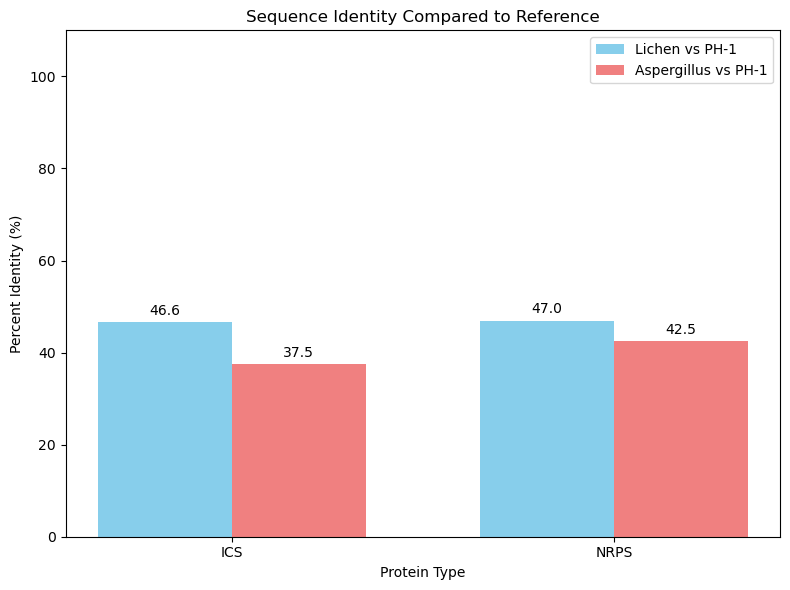

In [93]:
import os
from Bio import SeqIO
from Bio import pairwise2
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import substitution_matrices # To load scoring matrices
import matplotlib.pyplot as plt # Import matplotlib
import numpy as np # Import numpy for bar plotting positions

# --- Helper function to calculate percent identity ---
def calculate_percent_identity(alignment):
    """Calculates percent identity from a pairwise2 alignment tuple."""
    if not alignment:
        return 0.0

    seq1_aligned = alignment[0]
    seq2_aligned = alignment[1]
    alignment_length = len(seq1_aligned)
    matches = 0
    gaps = 0

    if alignment_length == 0:
        return 0.0

    for i in range(alignment_length):
        if seq1_aligned[i] == seq2_aligned[i] and seq1_aligned[i] != '-':
            matches += 1
        # Optional: Count gaps if you want identity excluding gaps
        # if seq1_aligned[i] == '-' or seq2_aligned[i] == '-':
        #     gaps += 1

    # Calculate identity (adjust denominator if excluding gaps)
    # Avoid division by zero if alignment_length is 0 after gap exclusion (if implemented)
    # current_denom = alignment_length - gaps
    current_denom = alignment_length
    if current_denom <= 0:
        return 0.0
    percent_id = (matches / current_denom) * 100
    return percent_id

# --- 1. Load Data and Reference Sequences ---
try:
    # Define file paths
    ref_nrps_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/NRPS_align.faa"
    ref_ics_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/ICS_align.faa"
    lichen_nrps_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/Lichen_NRPS.faa"
    lichen_ics_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/Lichen_ICS.faa"
    asp_nrps_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/aspLentulus_nrps.faa"
    asp_ics_path = "/Volumes/T7/MiscProjects/Singh/Fusarium data-ICS/aspLentulus_ics.faa"

    # Load reference sequences (ensure these files contain only ONE sequence each)
    ph1NRPS_record = SeqIO.read(ref_nrps_path, "fasta")
    ph1ICS_record = SeqIO.read(ref_ics_path, "fasta")

    # Load the lichen sequences
    lichen_NRPS_record = SeqIO.read(lichen_nrps_path, "fasta")
    lichen_ICS_record = SeqIO.read(lichen_ics_path, "fasta")

    # Load the Aspergillus sequences
    asp_NRPS_record = SeqIO.read(asp_nrps_path, "fasta")
    asp_ICS_record = SeqIO.read(asp_ics_path, "fasta")


    # Extract the sequence strings from the records
    ph1NRPS_seq = str(ph1NRPS_record.seq)
    ph1ICS_seq = str(ph1ICS_record.seq)
    lichen_NRPS_seq = str(lichen_NRPS_record.seq)
    lichen_ICS_seq = str(lichen_ICS_record.seq)
    asp_NRPS_seq = str(asp_NRPS_record.seq)
    asp_ICS_seq = str(asp_ICS_record.seq)


    print(f"Reference ICS sequence length: {len(ph1ICS_seq)}")
    print(f"Reference NRPS sequence length: {len(ph1NRPS_seq)}")
    print(f"Lichen ICS sequence length: {len(lichen_ICS_seq)}")
    print(f"Lichen NRPS sequence length: {len(lichen_NRPS_seq)}")
    print(f"Aspergillus ICS sequence length: {len(asp_ICS_seq)}")
    print(f"Aspergillus NRPS sequence length: {len(asp_NRPS_seq)}")


except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    exit()
except ValueError as e:
    print(f"Error reading FASTA file (ensure only one sequence per file): {e}")
    exit()
except Exception as e:
    print(f"An error occurred during loading: {e}")
    exit()

# --- 2. Perform Alignments and Calculate Metrics ---

print("\nPerforming alignments...")

# Define alignment parameters
gap_open = -10
gap_extend = -0.5

# Dictionary to store results (Percent Identity)
results = {
    "Lichen_ICS": 0.0,
    "Lichen_NRPS": 0.0,
    "Aspergillus_ICS": 0.0,
    "Aspergillus_NRPS": 0.0
}

# --- Align Lichen ICS vs Reference ICS ---
try:
    alignments_ics_lichen = pairwise2.align.globalxx(ph1ICS_seq, lichen_ICS_seq, one_alignment_only=True)
    if alignments_ics_lichen:
        ics_alignment_lichen = alignments_ics_lichen[0]
        results["Lichen_ICS"] = calculate_percent_identity(ics_alignment_lichen)
        print(f"\nLichen ICS vs Reference ICS:")
        print(f"  Alignment Score: {ics_alignment_lichen[2]}")
        print(f"  Percent Identity: {results['Lichen_ICS']:.2f}%")
    else: print("\nNo alignment found for Lichen ICS vs Reference ICS.")
except Exception as e: print(f"\nError during Lichen ICS alignment: {e}")

# --- Align Lichen NRPS vs Reference NRPS ---
try:
    alignments_nrps_lichen = pairwise2.align.globalxx(ph1NRPS_seq, lichen_NRPS_seq, one_alignment_only=True)
    if alignments_nrps_lichen:
        nrps_alignment_lichen = alignments_nrps_lichen[0]
        results["Lichen_NRPS"] = calculate_percent_identity(nrps_alignment_lichen)
        print(f"\nLichen NRPS vs Reference NRPS:")
        print(f"  Alignment Score: {nrps_alignment_lichen[2]}")
        print(f"  Percent Identity: {results['Lichen_NRPS']:.2f}%")
    else: print("\nNo alignment found for Lichen NRPS vs Reference NRPS.")
except Exception as e: print(f"\nError during Lichen NRPS alignment: {e}")

# --- 3. Align Aspergillus vs Reference ---

# --- Align Aspergillus ICS vs Reference ICS ---
try:
    alignments_ics_asp = pairwise2.align.globalxx(ph1ICS_seq, asp_ICS_seq, one_alignment_only=True)
    if alignments_ics_asp:
        ics_alignment_asp = alignments_ics_asp[0]
        results["Aspergillus_ICS"] = calculate_percent_identity(ics_alignment_asp)
        print(f"\nAspergillus ICS vs Reference ICS:")
        print(f"  Alignment Score: {ics_alignment_asp[2]}")
        print(f"  Percent Identity: {results['Aspergillus_ICS']:.2f}%")
    else: print("\nNo alignment found for Aspergillus ICS vs Reference ICS.")
except Exception as e: print(f"\nError during Aspergillus ICS alignment: {e}")

# --- Align Aspergillus NRPS vs Reference NRPS ---
try:
    alignments_nrps_asp = pairwise2.align.globalxx(ph1NRPS_seq, asp_NRPS_seq, one_alignment_only=True)
    if alignments_nrps_asp:
        nrps_alignment_asp = alignments_nrps_asp[0]
        results["Aspergillus_NRPS"] = calculate_percent_identity(nrps_alignment_asp)
        print(f"\nAspergillus NRPS vs Reference NRPS:")
        print(f"  Alignment Score: {nrps_alignment_asp[2]}")
        print(f"  Percent Identity: {results['Aspergillus_NRPS']:.2f}%")
    else: print("\nNo alignment found for Aspergillus NRPS vs Reference NRPS.")
except Exception as e: print(f"\nError during Aspergillus NRPS alignment: {e}")


# --- 4. Visualize Results ---
print("\nGenerating plot...")

# Prepare data for plotting
labels = ['ICS', 'NRPS'] # Groups on x-axis
lichen_ids = [results["Lichen_ICS"], results["Lichen_NRPS"]]
aspergillus_ids = [results["Aspergillus_ICS"], results["Aspergillus_NRPS"]]

x = np.arange(len(labels))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(8, 6)) # Create figure and axes object

# Create the bars for Lichen and Aspergillus side-by-side
rects1 = ax.bar(x - width/2, lichen_ids, width, label='Lichen vs PH-1', color='skyblue')
rects2 = ax.bar(x + width/2, aspergillus_ids, width, label='Aspergillus vs PH-1', color='lightcoral')

# Add labels, title, and ticks
ax.set_ylabel('Percent Identity (%)')
ax.set_xlabel('Protein Type')
ax.set_title('Sequence Identity Compared to Reference')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add text labels above bars (optional)
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

# Set y-axis limit (optional, ensures space for labels)
ax.set_ylim(0, 110) # Adjust max value if needed

fig.tight_layout() # Adjust layout

# Display the plot
# plt.show()

# Optional: Save the plot
saveHere = "/Volumes/T7/MiscProjects/Singh/Plots/sequence_identity_comparison.svg"
fig.savefig(saveHere)

print("\nScript finished.")


In [94]:
## print the version of matplotlib
import matplotlib
print(matplotlib.__version__)

3.7.1


# Get Lecanoromycetes antismash results

In [1]:
import pandas as pd
import os
import pdb

supTable1 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
lec = supTable1[supTable1['Fungal_Class'] == 'Lecanoromycetes']
lecAccessions = lec['Accession'].unique().tolist()

downloadCMD_base = 'scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/'
downloadHere = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti/'
for acc in lecAccessions:
	downloadCMD = downloadCMD_base + f'{acc}/{acc}_parsed_new_hybrids_anti_fix_ncbi {downloadHere}'
	print(downloadCMD)
	os.system(downloadCMD)
	downloadCMD

scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_014066305.1/GCA_014066305.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti/
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_014066315.1/GCA_014066315.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti/
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_018902385.1/GCA_018902385.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti/
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_019456465.1/GCA_019456465.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti/
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_022813765.1/GCA_022813765.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsA

In [46]:
### doing this for every accession now
import pandas as pd
import os
import pdb

supTable1 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
allAccs = supTable1['Accession'].unique().tolist()

downloadCMD_base = 'scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/'
downloadHere = '/Volumes/T7/MiscProjects/Singh/April_FinalWork/AllAccessions_Anti'
for acc in lecAccessions:
	downloadCMD = downloadCMD_base + f'{acc}/{acc}_parsed_new_hybrids_anti_fix_ncbi {downloadHere}'
	print(downloadCMD)
	os.system(downloadCMD)
	downloadCMD

scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_014066305.1/GCA_014066305.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/AllAccessions_Anti
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_014066315.1/GCA_014066315.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/AllAccessions_Anti
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_018902385.1/GCA_018902385.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/AllAccessions_Anti
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_019456465.1/GCA_019456465.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_FinalWork/AllAccessions_Anti
scp gnickles@ap2001.chtc.wisc.edu:/home/groups/keller_group/FungalGenomes/GCA_022813765.1/GCA_022813765.1_parsed_new_hybrids_anti_fix_ncbi /Volumes/T7/MiscProjects/Singh/April_Fina

In [43]:
## final Table
antiParsed_lec = pd.DataFrame(columns=['Accession', 'NumBGCs'])
# populate accessions with lecAccessions
antiParsed_lec['Accession'] = lecAccessions
antiParsed_lec['NumBGCs'] = 0
#
antiParsedFiles = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/CheckLecsAnti"
for file in os.listdir(antiParsedFiles):
	if file.startswith('GC') and file.endswith('_anti_fix_ncbi'):
		## get the accession number
		accession = "_".join(file.split('_')[0:2])
		filePath = os.path.join(antiParsedFiles, file)
		columns = ['BGCNum','Contig','Protein','misc1','mics2','start','stop','strand','info','BGC_Type']
		accAnti = pd.read_csv(filePath, sep='\t', header=None, names=columns)
		accAnti.columns = columns
		## the BGC_Type column has a space and reads the BGC_Type for the backbone proteins
		accAnti['BGC_Type'] = accAnti['BGC_Type'].str.split(' ').str[0]
		accAnti.drop_duplicates(subset=['BGCNum','BGC_Type'], inplace=True)
		#
		BGC_TypesCounts = accAnti['BGC_Type'].value_counts()
		## For each bgc type we will first check if it's a column, if not make it, if it is update the value for this accession
		for bgc in BGC_TypesCounts.index:
			if bgc not in antiParsed_lec.columns:
				antiParsed_lec[bgc] = 0
			antiParsed_lec.loc[antiParsed_lec['Accession'] == accession, bgc] = BGC_TypesCounts[bgc]

## adding in the ICS to this from supTable1
supTable1 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
lecRows = supTable1[supTable1['Accession'].isin(lecAccessions)]
lecRows = lecRows[['Accession', 'ICS_Count']]
antiParsed_lec = pd.merge(antiParsed_lec, lecRows, how='left', left_on='Accession', right_on='Accession')
# update the NumBGCs column to be the sum of all the BGCs
antiParsed_lec['NumBGCs'] = antiParsed_lec.iloc[:, 2:-1].sum(axis=1)

#sort the columns by the value of the columns (highest being column 3 and lowest being the last column). Accession and NumBGCs are not sorted
sumOfColumns = antiParsed_lec.iloc[:, 2:].sum(axis=0)
# Sort the columns by their sum
sorted_columns = sumOfColumns.sort_values(ascending=False).index.tolist()
# Reorder the DataFrame columns
antiParsed_lec = antiParsed_lec[['Accession', 'NumBGCs'] + sorted_columns]

In [45]:
antiParsed_lec

,Accession,NumBGCs,T1PKS,NRPS-like,terpene,NRPS,"NRPS,T1PKS",ICS_Count,indole,T3PKS,...,"NRPS,indole",other,"NRPS,terpene","NRPS-like,terpene","NRPS,betalactone","NRPS,NRPS-like","NRPS,T1PKS,indole,terpene","NRPS-like,T1PKS,indole","NRPS-like,fungal-RiPP","NRPS-like,T3PKS"
0,GCA_014066305.1,42,14,12,5,2,3,0,3,1,...,0,0,0,0,0,0,0,0,0,0
1,GCA_014066315.1,46,14,12,6,3,4,0,2,1,...,0,0,0,0,0,0,0,0,0,0
2,GCA_018902385.1,73,17,14,14,12,3,1,1,1,...,1,1,2,0,0,0,0,0,0,0
3,GCA_019456465.1,34,14,5,6,6,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,GCA_022813765.1,31,15,6,5,2,0,3,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,GCA_023647215.1,55,23,9,7,5,4,1,0,2,...,0,1,0,0,0,0,0,0,0,0
57,GCA_900169345.1,26,15,2,6,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
58,GCF_014066305.1,42,14,12,5,2,3,0,3,1,...,0,0,0,0,0,0,0,0,0,0
59,GCF_014066315.1,46,14,12,6,3,4,0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [24]:
columns = ['BGCNum','Contig','ContigEdit','Protein','misc1','mics2','start','stop','strand','info','BGC_Type']
accAnti = pd.read_csv(filePath, sep='\t', header=None, names=columns)
## the BGC_Type column has a space and reads the BGC_Type for the backbone proteins
accAnti['BGC_Type'] = accAnti['BGC_Type'].str.split(' ').str[0]

accAnti.drop_duplicates(subset=['BGCNum','BGC_Type'], inplace=True)
numBGCs = len(accAnti)
## update the number of BGCs in the antiParsed_lec table
antiParsed_lec.loc[antiParsed_lec['Accession'] == accession, 'NumBGCs'] = numBGCs

In [25]:
accAnti

,BGCNum,Contig,ContigEdit,Protein,misc1,mics2,start,stop,strand,info,BGC_Type
0,1,677mF-Z1.region001,677mF-Z1,XP_044673438.1,rna-XM_044809531.1,rna-XM_044809531.1,585340,587542,-,ID=rna-XM_044809531.1;Parent=gene-KY384_000999...,terpene
6,2,677mF-Z1.region002,677mF-Z1,XP_044673590.1,rna-XM_044809683.1,rna-XM_044809683.1,1184262,1186346,+,ID=rna-XM_044809683.1;Parent=gene-KY384_001151...,"NRPS-like,T1PKS"
13,3,677mF-Z1.region003,677mF-Z1,XP_044673699.1,rna-XM_044809792.1,rna-XM_044809792.1,1590026,1591958,+,ID=rna-XM_044809792.1;Parent=gene-KY384_001261...,NRPS
16,4,677mF-Z11.region001,677mF-Z11,XP_044669429.1,rna-XM_044814128.1,rna-XM_044814128.1,1861279,1867000,-,ID=rna-XM_044814128.1;Parent=gene-KY384_005629...,NRPS
27,5,677mF-Z13.region001,677mF-Z13,XP_044668149.1,rna-XM_044815049.1,rna-XM_044815049.1,1132533,1135813,+,ID=rna-XM_044815049.1;Parent=gene-KY384_006555...,terpene
35,6,677mF-Z14.region001,677mF-Z14,XP_044667838.1,rna-XM_044815220.1,rna-XM_044815220.1,37476,41221,-,ID=rna-XM_044815220.1;Parent=gene-KY384_006727...,NRPS
44,7,677mF-Z14.region002,677mF-Z14,XP_044667847.1,rna-XM_044815229.1,rna-XM_044815229.1,84073,84717,-,ID=rna-XM_044815229.1;Parent=gene-KY384_006736...,terpene
49,8,677mF-Z15.region001,677mF-Z15,XP_044667140.1,rna-XM_044815266.1,rna-XM_044815266.1,108568,110585,-,ID=rna-XM_044815266.1;Parent=gene-KY384_006773...,T1PKS
64,9,677mF-Z15.region002,677mF-Z15,XP_044667563.1,rna-XM_044815689.1,rna-XM_044815689.1,1468040,1469038,+,ID=rna-XM_044815689.1;Parent=gene-KY384_007197...,NRPS
77,10,677mF-Z15.region003,677mF-Z15,XP_044667614.1,rna-XM_044815740.1,rna-XM_044815740.1,1608184,1608836,-,ID=rna-XM_044815740.1;Parent=gene-KY384_007249...,T1PKS


## Making the sup table with which lichens have a previously characterized protein

In [6]:
allHits['Remove'].unique()

array([nan])

In [9]:
import pandas as pd

allHits = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/FinalMetaTable_April25_EditedAccessions.tsv", sep='\t')

##
allHits['ManualLabel'] = allHits['ManualLabel'].fillna("No")  # Fill NaN with False for ManualLabel
allHits['ManualLabel'] = allHits['ManualLabel'].astype(str)
supTable = allHits[(allHits['Lichen'] == 'Lichen') & (allHits['ManualLabel'] != 'No')]
# remove lichengroup1, lichengroup2, and crm_split from the table
supTable = supTable[~supTable['ManualLabel'].isin(['lichengroup1', 'lichengroup2', 'crm_split'])]
supTable

,Remove,TreeTip_Name,DB_Location,Accession,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,...,Species,Buscos (out of 290),BuscoScore,2023Nickles-etal_ClusterName,2023Nickles-etal__Dereplicated_GCF,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen,MatchingNameInFasta,EditedAccession
171,NaN,Vezdaea_aestivalis_M1814_004225,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gcf_4,Lichen,Vezdaea_aestivalis_M1814_004225_Singh,Vezdaea_aestivalis
268,NaN,Trapelia_coarctata_MCJ1249024.1,NCBI,GCA_022813945.1,MCJ1249024.1,Fungi,Ascomycota,Lecanoromycetes,Trapeliales,Trapeliaceae,...,Trapelia_coarctata,280.0,0.965517,NaN,NaN,NaN,gcf_4,Lichen,MCJ1249024.1_GCA_022813945.1,GCA_022813945.1
269,NaN,Trapelia_coarctata_MCJ1248508.1,NCBI,GCA_022813945.1,MCJ1248508.1,Fungi,Ascomycota,Lecanoromycetes,Trapeliales,Trapeliaceae,...,Trapelia_coarctata,280.0,0.965517,NaN,NaN,NaN,gcf_7,Lichen,MCJ1248508.1_GCA_022813945.1,GCA_022813945.1
303,NaN,Teloschistes_peruensis_KAI4109238.1,NCBI,GCA_023645835.1,KAI4109238.1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,...,Teloschistes_peruensis,274.0,0.944828,NaN,NaN,NaN,gcf_4,Lichen,KAI4109238.1_GCA_023645835.1,GCA_023645835.1
767,NaN,Letrouitia_transgressa_KAI4211283.1,NCBI,GCA_023646045.1,KAI4211283.1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Letrouitiaceae,...,Letrouitia_transgressa,270.0,0.931034,NaN,NaN,NaN,gcf_4,Lichen,KAI4211283.1_GCA_023646045.1,GCA_023646045.1
1548,NaN,Caloplaca_ligustica_KAI4139802.1,NCBI,GCA_023645885.1,KAI4139802.1,Fungi,Ascomycota,Lecanoromycetes,Teloschistales,Teloschistaceae,...,Caloplaca_ligustica,245.0,0.844828,NaN,NaN,NaN,gcf_4,Lichen,KAI4139802.1_GCA_023645885.1,GCA_023645885.1


# Adding tax to the new sup table with lichengroup 3 and 4

In [4]:
taxInfo

,TreeTip_Name,DB_Location,Accession,Protein,Kingdom,Phylum,Fungal_Class,Order,Family,Genus,Species,Buscos (out of 290),BuscoScore,2023Nickles-etal_ClusterName,2023Nickles-etal__Dereplicated_GCF,2023Nickles-etal__Manually_collapsedGCF,ManualLabel,Lichen
0,Kluyveromyces_lactis_CAH01350.1,NCBI,GCA_000002515.1,CAH01350.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Kluyveromyces,Kluyveromyces_lactis,288.0,0.993103,NaN,NaN,NaN,NaN,NaN
1,Candida_glabrata_CAG59009.1,NCBI,GCA_000002545.2,CAG59009.1,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,Candida_glabrata,281.0,0.968966,NaN,NaN,NaN,NaN,NaN
2,Aspergillus_clavatus_EAW12213.1,NCBI,GCA_000002715.1,EAW12213.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,8_Aspergillus_clavatus,5.0,NaN,NaN,NaN
3,Aspergillus_clavatus_EAW12218.1,NCBI,GCA_000002715.1,EAW12218.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,10_Aspergillus_clavatus,5.0,NaN,NaN,NaN
4,Aspergillus_clavatus_EAW12455.1,NCBI,GCA_000002715.1,EAW12455.1,Fungi,Ascomycota,Eurotiomycetes,Eurotiales,Aspergillaceae,Aspergillus,Aspergillus_clavatus,286.0,0.986207,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,Vezdaea_aestivalis_M1814_002798,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen
1921,Sticta_canariensis_MMC29_002054,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen
1922,Vezdaea_aestivalis_M1814_004225,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gcf_4,Lichen
1923,Arctoparmelia_centrifuga_FUN_000441,Lichen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lichen


In [36]:

#  date: January 5, 2025
import pandas as pd
import pdb
import os

taxInfo_full = pd.read_csv("//Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/Filtered_MetaTable_LFF3-4.tsv", sep='\t')
## grabbing the columns we want
cols = ['TreeTip_Name', 'Kingdom', 'Order', 'Family', 'Genus']
taxInfo = taxInfo_full[cols]
correctGroups = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/ICS_Meta.tsv", sep='\t')
## drop these columns from correctGroups
dropCols = ['tip_offset','LichenStatus']
correctGroups = correctGroups.drop(columns=dropCols)

merge = pd.merge(correctGroups, taxInfo, how='left', on='TreeTip_Name', )
# reorder the tax columns to be at the end but in the order of Kingdom, Order, Family, Genus..
taxCols = ['Kingdom', 'Order', 'Family', 'Genus', 'Species','Accession']
otherCols = [col for col in merge.columns if col not in taxCols]
finalCols = otherCols + taxCols
merge = merge[finalCols]
merge

## gcf 7 is in the tax but not the merge, so we will manually add it over
gcf7 = taxInfo_full[taxInfo_full['ManualLabel'] == 'gcf_7']
gcf7_tips = gcf7['TreeTip_Name'].unique().tolist()
## updating the merge table for these tips
merge.loc[merge['TreeTip_Name'].isin(gcf7_tips), 'ManualLabel'] = "gcf_7"

## do the same for the dits 
## change all NaN in taxInfo_full to "NaN" string
taxInfo_full = taxInfo_full.fillna("NaN")
dits = taxInfo_full[taxInfo_full['2023Nickles-etal__Manually_collapsedGCF'].str.startswith('dit')]
dit_tips = dits['TreeTip_Name'].unique().tolist()

# get the number of rows being changed to print as well 
num_dit_rows = merge.loc[merge['TreeTip_Name'].isin(dit_tips)].shape[0]
print(f"Number of rows being changed to 'dit': {num_dit_rows}")
merge.loc[merge['TreeTip_Name'].isin(dit_tips), 'ManualLabel'] = "dit"

#### Updating the lichen group 3 version 2 as well
newVersion_3 = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/newVersion3_Meta.tsv", sep='\t')
newVersion_3 = newVersion_3[['ID', 'ManualLabel']]
# rename the ID column to TreeTip_Name
newVersion_3 = newVersion_3.rename(columns={'ID': 'TreeTip_Name'})
newV3_rows = newVersion_3[newVersion_3['ManualLabel'] == 'lichengroup3_subset2']
newV3_tips = newV3_rows['TreeTip_Name'].unique().tolist()

#
merge.loc[merge['TreeTip_Name'].isin(newV3_tips), 'ManualLabel'] = "lichengroup3_subset2"
# save the merged table
savePath = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/ICS_Meta_withTaxonomy.tsv"
merge.to_csv(savePath, sep='\t', index=False)


Number of rows being changed to 'dit': 91


In [37]:
newV3_tips

['Xanthoria_steineri_KAI4222085.1',
 'Xanthoria_sp_2_TBL2021_KAI4283325.1',
 'Xanthoria_mediterranea_KAI4095895.1',
 'Xanthoria_aureola_KAI4221412.1',
 'Xanthomendoza_cf_fulva_KAI4234921.1',
 'Umbilicaria_pustulata',
 'Trapelia_coarctata_MCJ1248313.1',
 'Teloschistes_peruensis_KAI4098417.1',
 'Teloschistes_peruensis_KAI4093034.1',
 'Teloschistes_flavicans_KAI4254493.1',
 'Rusavskia_elegans',
 'Niorma_chrysophthalma_KAI4199784.1',
 'Letrouitia_leprolyta_KAI4189289.1',
 'Lasallia_pustulata_SLM34376.1',
 'Hypocenomyce_scalaris_MCJ1303210.1',
 'Gyalolechia_ehrenbergii_KAI4177494.1',
 'Caloplaca_ligustica_KAI4148944.1']

In [ ]:
#### For the subset 2 guys, copy over those gbks into its own folder 
##
newV4_tips
baseDir = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/LichenGroup4"
newDir = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/LichenGroup4_Subset2"

for tip in newV4_tips


In [31]:
## Renaming the gbk files to have the species and accession number in the filename

gbkFilesPath = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4"
icsTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/ICS_Meta_withTaxonomy.tsv", sep='\t')
icsTable['ICS_Protein'] = ""
## For TreeTip_Name that have XP_, to get the prot we need to split and grab -2:
## For all of the other accessions we grab -1
for index, row in icsTable.iterrows():
	if 'XP_' in row['TreeTip_Name'] or "FUN_" in row['TreeTip_Name']:
		prot = "_".join(row['TreeTip_Name'].split('_')[-2:])
	else:
		prot = row['TreeTip_Name'].split('_')[-1]
	icsTable.at[index, 'ICS_Protein'] = prot

for folder in os.listdir(gbkFilesPath):
	folderPath = os.path.join(gbkFilesPath, folder)
	if os.path.isdir(folderPath) and folder.startswith("Lichen"):
		for file in os.listdir(folderPath):
			if not file.startswith(".") and file.endswith(".gbk"):
				prot = file.split("_flanking")[0]
				## get the row in icsTable with this prot
				row = icsTable[icsTable['ICS_Protein'] == prot]
				if not row.empty:
					species = row['Species'].values[0]
					accession = row['Accession'].values[0]
					newFileName = f"{species}_{accession}_{prot}.gbk"
					oldFilePath = os.path.join(folderPath, file)
					newFilePath = os.path.join(folderPath, newFileName)
					os.rename(oldFilePath, newFilePath)
					print(f"Renamed {file} to {newFileName}")
				else:
					print(f"Protein {prot} not found in ICS table.")

Renamed CRL21119.1_flanking.gbk to Penicillium_camemberti_GCA_000513335.1_CRL21119.1.gbk
Renamed EAW12218.1_flanking.gbk to Aspergillus_clavatus_GCA_000002715.1_EAW12218.1.gbk
Renamed EAW25559.1_flanking.gbk to Aspergillus_fischeri_GCA_000149645.3_EAW25559.1.gbk
Renamed EPS26252.1_flanking.gbk to Penicillium_oxalicum_GCA_000346795.1_EPS26252.1.gbk
Renamed GIC94487.1_flanking.gbk to Aspergillus_udagawae_GCA_001078395.2_GIC94487.1.gbk
Renamed KAF4238999.1_flanking.gbk to Aspergillus_fumigatiaffinis_GCA_012656225.1_KAF4238999.1.gbk
Renamed KAF7521114.1_flanking.gbk to Penicillium_crustosum_GCA_014621375.1_KAF7521114.1.gbk
Renamed KAF7712287.1_flanking.gbk to Penicillium_sp_RFL2021a_GCA_014839625.1_KAF7712287.1.gbk
Renamed KAI4132389.1_flanking.gbk to Usnochroma_carphineum_GCA_023645975.1_KAI4132389.1.gbk
Renamed KAI4169800.1_flanking.gbk to Gyalolechia_ehrenbergii_GCA_023646125.1_KAI4169800.1.gbk
Renamed KAI4182038.1_flanking.gbk to Letrouitia_leprolyta_GCA_023646175.1_KAI4182038.1.gbk
Re

In [15]:
## Renaming the gbk files to have the species and accession number in the filename

gbkFilesPath = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/EditedSubset"
saveHere = "/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LichenGroup1/EditedSubset_Renamed"
icsTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/ICS_Meta_withTaxonomy.tsv", sep='\t')
icsTable['ICS_Protein'] = ""
## For TreeTip_Name that have XP_, to get the prot we need to split and grab -2:
## For all of the other accessions we grab -1
for index, row in icsTable.iterrows():
	if 'XP_' in row['TreeTip_Name'] or "FUN_" in row['TreeTip_Name']:
		prot = "_".join(row['TreeTip_Name'].split('_')[-2:])
	else:
		prot = row['TreeTip_Name'].split('_')[-1]
	icsTable.at[index, 'ICS_Protein'] = prot

for file in os.listdir(gbkFilesPath):
	if not file.startswith(".") and file.endswith(".gbk"):
		prot = file.split("_flanking")[0]
		## get the row in icsTable with this prot
		row = icsTable[icsTable['ICS_Protein'] == prot]
		if not row.empty:
			species = row['Species'].values[0]
			accession = row['Accession'].values[0]
			newFileName = f"{species}_{accession}_{prot}.gbk"
			oldFilePath = os.path.join(gbkFilesPath, file)
			newFilePath = os.path.join(saveHere, newFileName)
			os.rename(oldFilePath, newFilePath)
			print(f"Renamed {file} to {newFileName}")
		else:
			print(f"Protein {prot} not found in ICS table.")

Renamed KAF2201234.1_flanking.gbk to Delitschia_confertaspora_GCA_010093945.1_KAF2201234.1.gbk
Renamed KAF2488791.1_flanking.gbk to Lophium_mytilinum_GCA_010093605.1_KAF2488791.1.gbk
Renamed KAF2848073.1_flanking.gbk to Plenodomus_tracheiphilus_GCA_010093695.1_KAF2848073.1.gbk
Renamed KAF4307270.1_flanking.gbk to Botryosphaeria_dothidea_GCA_011503125.2_KAF4307270.1.gbk
Renamed KAF7507277.1_flanking.gbk to Endocarpon_pusillum_GCA_014607435.1_KAF7507277.1.gbk
Renamed KAH8728392.1_flanking.gbk to Phaeosphaeriaceae_sp_PMI808_GCA_021365335.1_KAH8728392.1.gbk
Renamed KAH9877667.1_flanking.gbk to Leptosphaeria_biglobosa_GCA_022343325.1_KAH9877667.1.gbk
Renamed KAI4123483.1_flanking.gbk to Usnochroma_carphineum_GCA_023645975.1_KAI4123483.1.gbk
Renamed KAI4125426.1_flanking.gbk to Usnochroma_carphineum_GCA_023645975.1_KAI4125426.1.gbk
Renamed KAI4154545.1_flanking.gbk to Variospora_aurantia_GCA_023645955.1_KAI4154545.1.gbk
Renamed KAI4172377.1_flanking.gbk to Gyalolechia_ehrenbergii_GCA_0236461

In [6]:
lichengroup1_species

array(['Xylographa_vitiligo', 'Xylographa_trunciseda',
       'Xylographa_soralifera', 'Xylographa_opegraphella',
       'Xylographa_bjoerkii_MMC18_002297', 'Xylographa_bjoerkii',
       'Variospora_aurantia', 'Usnochroma_carphineum',
       'Sticta_canariensis', 'Stereocaulon_alpinum',
       'Pseudocyphellaria_aurata', 'Plenodomus_tracheiphilus',
       'Phaeosphaeriaceae_sp_PMI808', 'Peltigera_leucophlebia',
       'Parmelia_saxatalis', 'Mytilinidion_resinicola',
       'Lophium_mytilinum', 'Lobaria_immixta', 'Lignoscripta_atroalba',
       'Letrouitia_leprolyta', 'Leptosphaeria_biglobosa',
       'Gyalolechia_ehrenbergii', 'Endocarpon_pusillum',
       'Delitschia_confertaspora', 'Cladonia_squamosa',
       'Cladonia_rangiferina_FUN_008814', 'Botryosphaeria_dothidea',
       'Arctoparmelia_centrifuga'], dtype=object)

In [11]:
import pandas as pd
import os
import pdb

#### Print some percents for the writing
table = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/ICS_Meta_withTaxonomy.tsv", sep='\t')
### For all rows where the species is blank, fill it with the tree tip name
table['Species'] = table.apply(lambda row: row['TreeTip_Name'] if pd.isna(row['Species']) or row['Species'] == "" else row['Species'], axis=1)

# print number of unique species with lichengroup3
lichengroup3_species = table[table['ManualLabel'] == 'lichengroup3_subset2']['Species'].unique()
num_lichengroup3_species = len(lichengroup3_species)
print(f"Number of unique species in lichengroup3: {num_lichengroup3_species}")
# what percent of these are lichen
group3 = table[table['ManualLabel'] == 'lichengroup3_subset2']
group3_lichen = group3[group3['Lichen'] == 'Lichen']
num_group3_lichen = len(group3_lichen['Species'].unique())
print(f"Number of unique lichen species in lichengroup3: {num_group3_lichen}")
percent_group3_lichen = (num_group3_lichen / num_lichengroup3_species) * 100
print(f"Percentage of lichen species in lichengroup3: {percent_group3_lichen}%")

# print number of unique species with lichengroup1
lichengroup1_species = table[table['ManualLabel'] == 'lichengroup1']['Species'].unique()
num_lichengroup1_species = len(lichengroup1_species) -1 # -1 removes the Xylographa_bjoerkii_MMC18_002297 since Xylographa_bjoerkii is already counted in lichengroup3
print(f"Number of unique species in lichengroup1: {num_lichengroup1_species}")
# what percent of these are lichen 
group3 = table[table['ManualLabel'] == 'lichengroup1']
group3_lichen = group3[group3['Lichen'] == 'Lichen']
num_group3_lichen = len(group3_lichen['Species'].unique())
print(f"Number of unique lichen species in lichengroup1: {num_group3_lichen}")
percent_group3_lichen = (num_group3_lichen / num_lichengroup1_species) * 100
print(f"Percentage of lichen species in lichengroup1: {percent_group3_lichen}%")

## LG4 now
lichengroup4_species = table[table['ManualLabel'] == 'lichengroup4']['Species'].unique()
num_lichengroup4_species = len(lichengroup4_species)
print(f"Number of unique species in lichengroup4: {num_lichengroup4_species}")
# what percent of these are lichen
group4 = table[table['ManualLabel'] == 'lichengroup4']
group4_lichen = group4[group4['Lichen'] == 'Lichen']
num_group4_lichen = len(group4_lichen['Species'].unique())
print(f"Number of unique lichen species in lichengroup4: {num_group4_lichen}")
percent_group4_lichen = (num_group4_lichen / num_lichengroup4_species) * 100
print(f"Percentage of lichen species in lichengroup4: {percent_group4_lichen}%")

Number of unique species in lichengroup3: 16
Number of unique lichen species in lichengroup3: 16
Percentage of lichen species in lichengroup3: 100.0%
Number of unique species in lichengroup1: 27
Number of unique lichen species in lichengroup1: 21
Percentage of lichen species in lichengroup1: 77.77777777777779%
Number of unique species in lichengroup4: 26
Number of unique lichen species in lichengroup4: 7
Percentage of lichen species in lichengroup4: 26.923076923076923%


### What was ran with zol
```sh
(zol_env) gnickles@SSITMMI-NKLAB12:/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4$ ls
ExtractLFF_BGC.py             ICS_Meta.tsv                  LichenGroup1                  LichenGroup3                  cgcg_Lichen3
Filtered_MetaTable_LFF3-4.tsv ICS_Meta_withTaxonomy.tsv     LichenGroup2                  LichenGroup4

(zol_env) gnickles@SSITMMI-NKLAB12:/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4$ zol -i LichenGroup3 -o zol_lichen3 
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Running zol version 1.5.13
--------------------
Step 1
--------------------
Searching for GenBanks in the input directory
Ignoring 0 files either because they did not meet requirements or filtering criteria.
Found 43 GenBanks in the input directory.
--------------------
Step 2
--------------------
Determining orthogroups
....
....
....
(zol_env) gnickles@SSITMMI-NKLAB12:/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4$ zol -i LichenGroup4 -o zol_lichen4 
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Running zol version 1.5.13
--------------------
Step 1
--------------------
Searching for GenBanks in the input directory
Ignoring 0 files either because they did not meet requirements or filtering criteria.
Found 24 GenBanks in the input directory.
--------------------
Step 2
--------------------
Determining orthogroups
--------------------
Step 3
--------------------
Creating alignments, trees and consensus sequences for ortholog groups
Running PAL2NAL to generate codon alignments for 264 ortholog groups
  0%|                                                                                                                                      | 0/264 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 264/264 [00:16<00:00, 15.92it/s]
Running trimal to generate trimmed protein and codon alignments for 264 ortholog groups
  0%|                                                                                                                                      | 0/528 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 528/528 [00:15<00:00, 34.34it/s]
Running FastTree 2 to generate gene trees (based on trimmed codon alignments) for 65 ortholog groups
  0%|                                                                                                                                       | 0/65 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [00:05<00:00, 11.06it/s]
Running HMMER3 hmmbuild to generate profile HMMs for 264 ortholog groups
  0%|                                                                                                                                      | 0/264 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 264/264 [00:40<00:00,  6.55it/s]
Running HMMER3 hmmemit to generate consensus protein sequences for 264 ortholog groups
  0%|                                                                                                                                      | 0/264 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 264/264 [00:12<00:00, 21.20it/s]
--------------------
Step 4
--------------------
Attempting to perform annotations (unless skipped)
Running pyhmmer hmmsearch for functional annotation for 2 databases
  0%|                                                                                                                                        | 0/2 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [01:27<00:00, 43.78s/it]
Running DIAMOND blastp for functional annotation for 0 databases
0it [00:00, ?it/s]
--------------------
Step 5
--------------------
Determining consensus order, conservation, and median lengths of ortholog groups
**********************************
WARNING!!! No core ortholog groups were detected across homologous gene cluster
instances - the consensus order and direction predictions will likely be lower quality.
**********************************
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
Warning: Total is zero, skipping ambiguity calculation for this alignment.
--------------------
Step 6
--------------------
Running evolutionary analyses
Computing Tajima's D statistic (using trimmed codon alignments) for 65 ortholog groups
  0%|                                                                                                                                       | 0/65 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [00:05<00:00, 11.10it/s]
Computing sequence and upstream sequence entropy for ortholog groups
  0%|                                                                                                                                      | 0/198 [00:00<?, ?it/s]Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 198/198 [00:12<00:00, 15.43it/s]
--------------------
Step 8
--------------------
Putting together final report
--------------------
Step 9
--------------------
Creating heatmap visualization of gene cluster representative instances
Non-unique labels resulted from truncating GenBank names. Please rerun zol with the "--full_genbank_labels" argument.

```


# Notes on tree re-run

What was ran:
[script path](/Volumes/T7/MiscProjects/Singh/April_FinalWork/crmTree/Tree_ReMake/ScriptRan.sh)


# Confirming the number of crm in species

In [33]:
import pandas as pd

finalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/GetNRPS_crm/NRPS_CRM_FinalTable.tsv", sep='\t')
ditFinalTable = pd.read_csv("/Volumes/T7/MiscProjects/Singh/April_FinalWork/ExtractLFFs_BGCs/LFF3_4/newVersionDIT_Meta.tsv", sep='\t')
allGenomes = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
ascosOnly = allGenomes[allGenomes['Phylum'] == 'Ascomycota']

### Total number of species 
total_genomes = ascosOnly['Accession'].nunique()
total_species = ascosOnly['Species'].nunique()

# grabbing only the rows where nrps_protein is not null
crm_ics = finalTable[finalTable['nrps_protein'].notnull()]
num_crm_genomes = crm_ics['Accession'].nunique()
num_crm_species = crm_ics['Species'].nunique()
# split by type
yes_crm = crm_ics[crm_ics['NRPS_attached_ICS?'] == 'Yes']
no_crm = crm_ics[crm_ics['NRPS_attached_ICS?'] == 'No']
num_yes_crm_genomes = yes_crm['Accession'].nunique()
num_no_crm_genomes = no_crm['Accession'].nunique()
num_yes_crm_species = yes_crm['Species'].nunique()
num_no_crm_species = no_crm['Species'].nunique()

# Number that are dit
dit_crm = ditFinalTable[ditFinalTable['ManualLabel'] == 'dit_supergroup']
num_dit_genomes = dit_crm['Accession'].nunique()
num_dit_species = dit_crm['Species'].nunique()

### Running the calcs
percent_nrps_crm = (num_crm_genomes / total_genomes) * 100
percent_dit_split = (num_dit_genomes / total_genomes) * 100
percent_yes_crm = (num_yes_crm_genomes / total_genomes) * 100
percent_no_crm = (num_no_crm_genomes / total_genomes) * 100

percentSP_nrps_crm = (num_crm_species / total_species) * 100
percentSP_dit_split = (num_dit_species / total_species) * 100
percentSP_yes_crm = (num_yes_crm_species / total_species) * 100
percentSP_no_crm = (num_no_crm_species / total_species) * 100

### Printing the results
print(f"Total genomes: {total_genomes}, Total species: {total_species}")
print(f"Genomes with NRPS-ICS: {num_crm_genomes} ({percent_nrps_crm:.2f}%), Species with NRPS-ICS: {num_crm_species} ({percentSP_nrps_crm:.2f}%)")
print(f"Genomes with dit split: {num_dit_genomes} ({percent_dit_split:.2f}%), Species with dit split: {num_dit_species} ({percentSP_dit_split:.2f}%)")
print(f"Genomes with Yes CRM: {num_yes_crm_genomes} ({percent_yes_crm:.2f}%), Species with Yes CRM: {num_yes_crm_species} ({percentSP_yes_crm:.2f}%)")
print(f"Genomes with No CRM: {num_no_crm_genomes} ({percent_no_crm:.2f}%), Species with No CRM: {num_no_crm_species} ({percentSP_no_crm:.2f}%)")

Total genomes: 2948, Total species: 1067
Genomes with NRPS-ICS: 281 (9.53%), Species with NRPS-ICS: 281 (26.34%)
Genomes with dit split: 367 (12.45%), Species with dit split: 367 (34.40%)
Genomes with Yes CRM: 136 (4.61%), Species with Yes CRM: 136 (12.75%)
Genomes with No CRM: 160 (5.43%), Species with No CRM: 160 (15.00%)


In [43]:
## We want to re-calc the numbers but remoev the Saccharomycetes; only using species
ascosOnly_noSac = ascosOnly[ascosOnly['Fungal_Class'] != 'Saccharomycetes']
num_species_noSac = ascosOnly_noSac['Species'].nunique()

## Getting the numbers again
crm_ics_noSac = crm_ics[~crm_ics['Species'].isin(ascosOnly[ascosOnly['Fungal_Class'] == 'Saccharomycetes']['Species'].unique().tolist())]
num_crm_species_noSac = crm_ics_noSac['Species'].nunique()
dit_crm_noSac = dit_crm[~dit_crm['Species'].isin(ascosOnly[ascosOnly['Fungal_Class'] == 'Saccharomycetes']['Species'].unique().tolist())]
num_dit_species_noSac = dit_crm_noSac['Species'].nunique()

## Printing the new results
percentSP_nrps_crm_noSac = (num_crm_species_noSac / num_species_noSac) * 100
percentSP_dit_split_noSac = (num_dit_species_noSac / num_species_noSac) * 100

print(f"After removing Saccharomycetes:")
print(f"Total species (no Saccharomycetes): {num_species_noSac}")
print(f"Species with NRPS-ICS (no Saccharomycetes): {num_crm_species_noSac} ({percentSP_nrps_crm_noSac:.2f}%)")
print(f"Species with dit split (no Saccharomycetes): {num_dit_species_noSac} ({percentSP_dit_split_noSac:.2f}%)")



After removing Saccharomycetes:
Total species (no Saccharomycetes): 938
Species with NRPS-ICS (no Saccharomycetes): 281 (29.96%)
Species with dit split (no Saccharomycetes): 285 (30.38%)


In [32]:
allGenomes = pd.read_csv("/Volumes/T7/MiscProjects/Singh/Paper/SupTable1_BuscoICSCounts.tsv", sep='\t')
ascosOnly = allGenomes[allGenomes['Phylum'] == 'Ascomycota']
UniqueSpecies = ascosOnly['Species'].unique().tolist()
numUniqueSpecies = len(UniqueSpecies)
print(f"Number of unique Ascomycete species: {numUniqueSpecies}")

## seeing how many of these have crm from the other table
finalTable['nrps_protein'].fillna('nan', inplace=True)
species_with_crm = finalTable.loc[finalTable['nrps_protein'] != 'nan', 'Species'].unique().tolist()
len_speciesWith_crm = len(species_with_crm)

## percent of ascomycetes with crm
percent_asco_with_crm = (len_speciesWith_crm / numUniqueSpecies) * 100
print(f"Percentage of Ascomycetes with CRM: {percent_asco_with_crm}%")


Number of unique Ascomycete species: 1067
Percentage of Ascomycetes with CRM: 26.33552014995314%


/var/folders/5g/1y9flghs3z771hm2c0f5zqy8nw7s5t/T/ipykernel_14102/3998648122.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  finalTable['nrps_protein'].fillna('nan', inplace=True)
